# Treinando os modelos com as features

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import warnings

# Silencia os avisos de paralelismo do scikit-learn
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

## Função para salvar a tabela de resultados

In [31]:
def save_results(model_name, category_name, y_true, y_pred, y_prob, file_name='resultados_modelos.csv'):
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    
    # Adicionada a chave 'Modelo' no dicionário
    new_result = pd.DataFrame([{
        'Modelo': model_name,
        'Categoria': category_name,
        'Accuracy': round(acc, 4),
        'Sensibilidade': round(sens, 4),
        'Especificidade': round(spec, 4),
        'F1': round(f1, 4),
        'AUC': round(auc, 4)
    }])
    
    if os.path.exists(file_name):
        new_result.to_csv(file_name, mode='a', header=False, index=False)
    else:
        new_result.to_csv(file_name, mode='w', header=True, index=False)
        
    return new_result

## Função geradora do dashboard

In [32]:
def plot_dashboard(model_name, y_true, y_pred, y_prob, category_name):
    fig, axs = plt.subplots(1, 3, figsize=(24, 7))
    
    fig.suptitle(f'{model_name} - {category_name}', fontsize=22, fontweight='bold')
    
    # Classification Report (Esquerda)
    ax_table = axs[0]
    ax_table.axis('off')
    ax_table.set_title('Classification Report (LOO)', fontsize=16, fontweight='bold', pad=20)
    
    report = classification_report(y_true, y_pred, target_names=['Controle (CN)', 'Alzheimer (AD)'], output_dict=True)
    row_labels = ['Controle (CN)', 'Alzheimer (AD)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    
    cell_text = []
    for row in ['Controle (CN)', 'Alzheimer (AD)']:
        cell_text.append([f"{report[row]['precision']:.2f}", f"{report[row]['recall']:.2f}", f"{report[row]['f1-score']:.2f}", f"{int(report[row]['support'])}"])
    cell_text.append(["", "", f"{report['accuracy']:.2f}", f"{int(report['macro avg']['support'])}"])
    for row in ['macro avg', 'weighted avg']:
        cell_text.append([f"{report[row]['precision']:.2f}", f"{report[row]['recall']:.2f}", f"{report[row]['f1-score']:.2f}", f"{int(report[row]['support'])}"])

    table = ax_table.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels, loc='center', cellLoc='center')
    table.scale(1, 2.5)
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_facecolor('#E66101') 
            cell.set_text_props(color='white', weight='bold')
        elif i == 2:
            cell.set_facecolor('#FFF5EB') 
    
    # Confusion Matrix (Centro)
    ax_cm = axs[1]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax_cm, 
                xticklabels=['CN', 'AD'], yticklabels=['CN', 'AD'], 
                annot_kws={"size": 14}, vmin=0, vmax=np.max(cm)*1.2)
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=16, fontweight='bold')
    ax_cm.set_ylabel('True label', fontsize=12)
    ax_cm.set_xlabel('Predicted label', fontsize=12)

    # ROC Curve (Direita)
    ax_roc = axs[2]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    
    ax_roc.plot(fpr, tpr, color='#E66101', lw=3, label=f'{model_name} (AUC = {auc_score:.3f})')
    ax_roc.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=16, fontweight='bold')
    ax_roc.legend(loc="lower right", fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    
    os.makedirs('images', exist_ok=True)
    img_name = f"dashboard_{model_name.replace(' ', '_')}_{category_name.replace(' ', '_')}.png"
    img_path = os.path.join('images', img_name)
    
    plt.savefig(img_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Dashboard salvo como: {img_path}")

## Função de treinamento (LOSO)

In [33]:
def evaluate_feature(df, feature_cols, category_name, model_name="Random Forest"):
    # AGRUPAMENTO: Tira a média das épocas para cada paciente
    df_grouped = df.groupby(['Subject_ID', 'Group'], as_index=False)[feature_cols].mean()
    
    # SEPARAÇÃO DE VARIÁVEIS
    X = df_grouped[feature_cols].values
    y = np.where(df_grouped['Group'] == 'A', 1, 0)
    groups = df_grouped['Subject_ID'].values
    
    # CONFIGURAÇÃO DO MODELO
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    loso = LeaveOneGroupOut()
    
    all_y_true = []
    all_y_pred = []
    all_y_prob = []
    
    print(f"\nTreinando {model_name} para: {category_name}...")
    
    # VALIDAÇÃO CRUZADA (Leave-One-Subject-Out)
    for train_idx, test_idx in loso.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf.fit(X_train, y_train)

        all_y_true.append(y_test[0])
        all_y_pred.append(clf.predict(X_test)[0])
        all_y_prob.append(clf.predict_proba(X_test)[0, 1])
        
    # SALVAMENTO E VISUALIZAÇÃO
    save_results(model_name, category_name, all_y_true, all_y_pred, all_y_prob)
    plot_dashboard(model_name, all_y_true, all_y_pred, all_y_prob, category_name)

## Random Forest

Iniciando a bateria de testes com 65 pacientes...


Treinando Random Forest para: Baseline (RBP)...


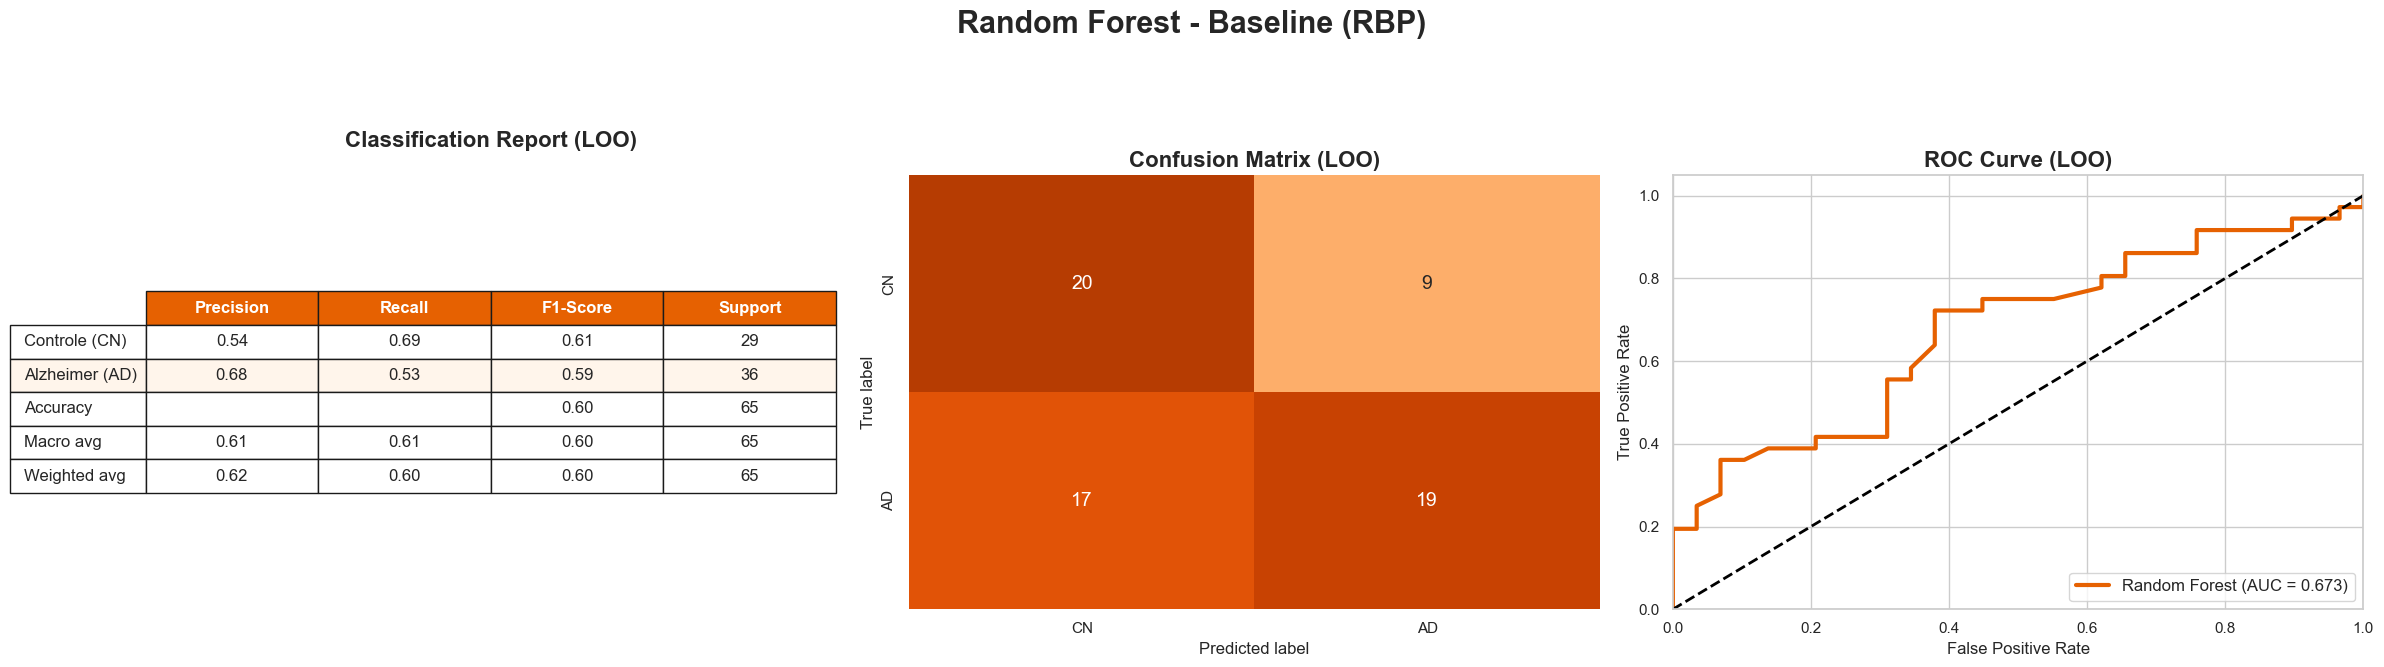

Dashboard salvo como: images\dashboard_Random_Forest_Baseline_(RBP).png

Treinando Random Forest para: Mean Frequency...


c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\i

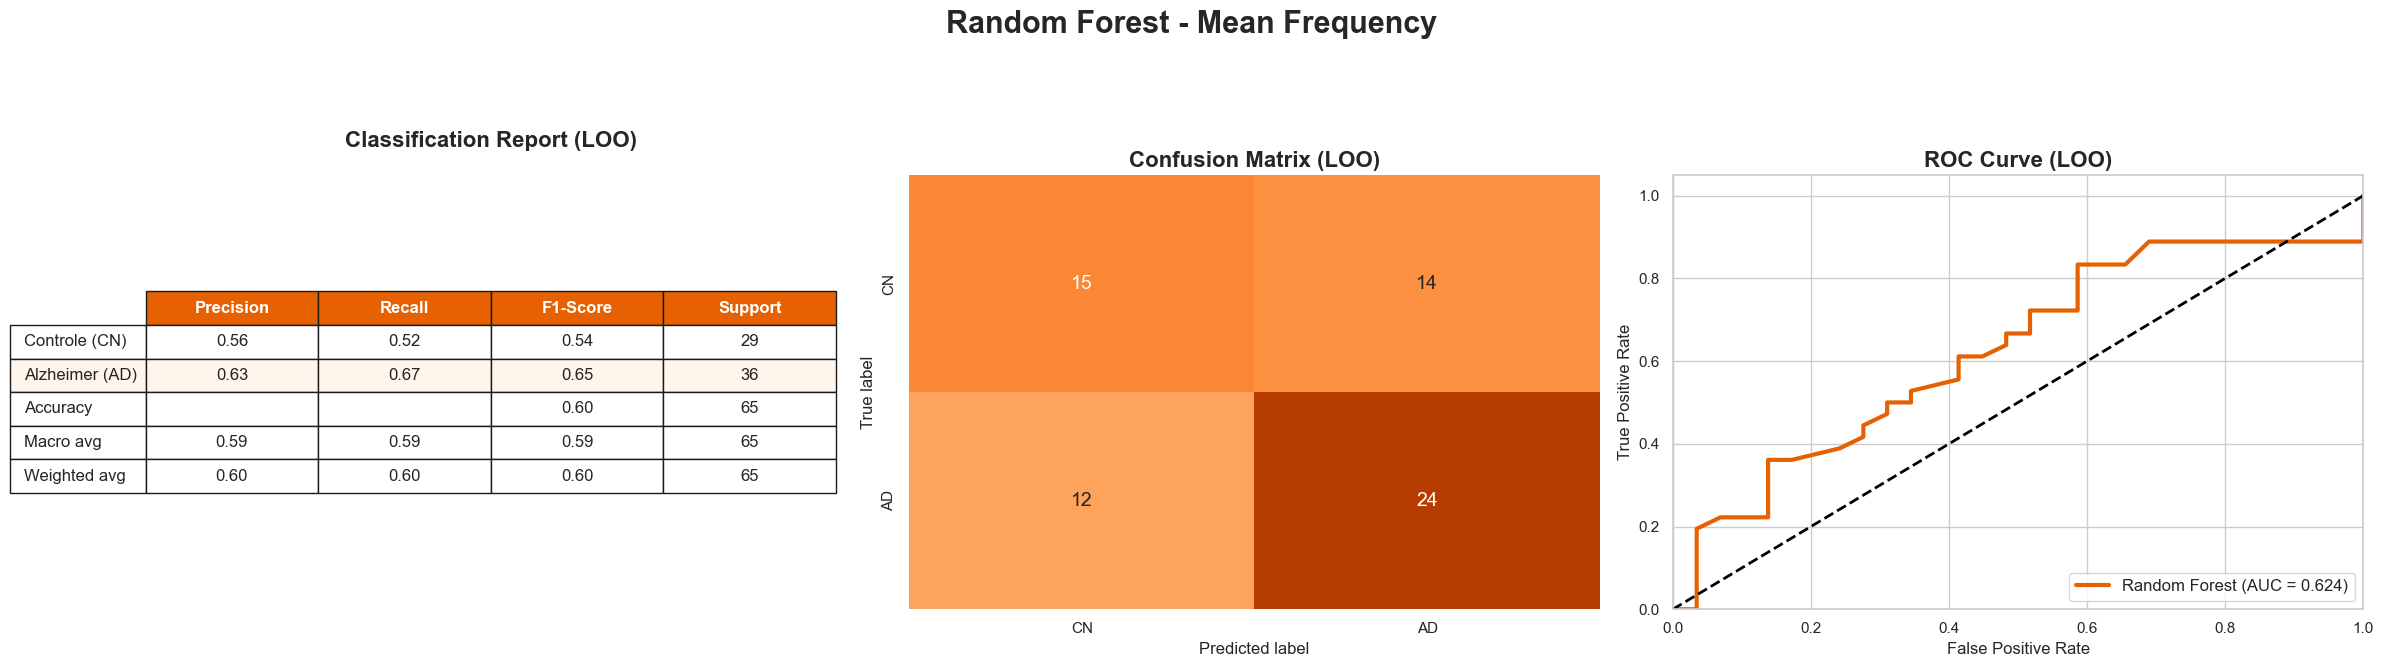

Dashboard salvo como: images\dashboard_Random_Forest_Mean_Frequency.png

Treinando Random Forest para: Lempel-Ziv Complexity...


c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\i

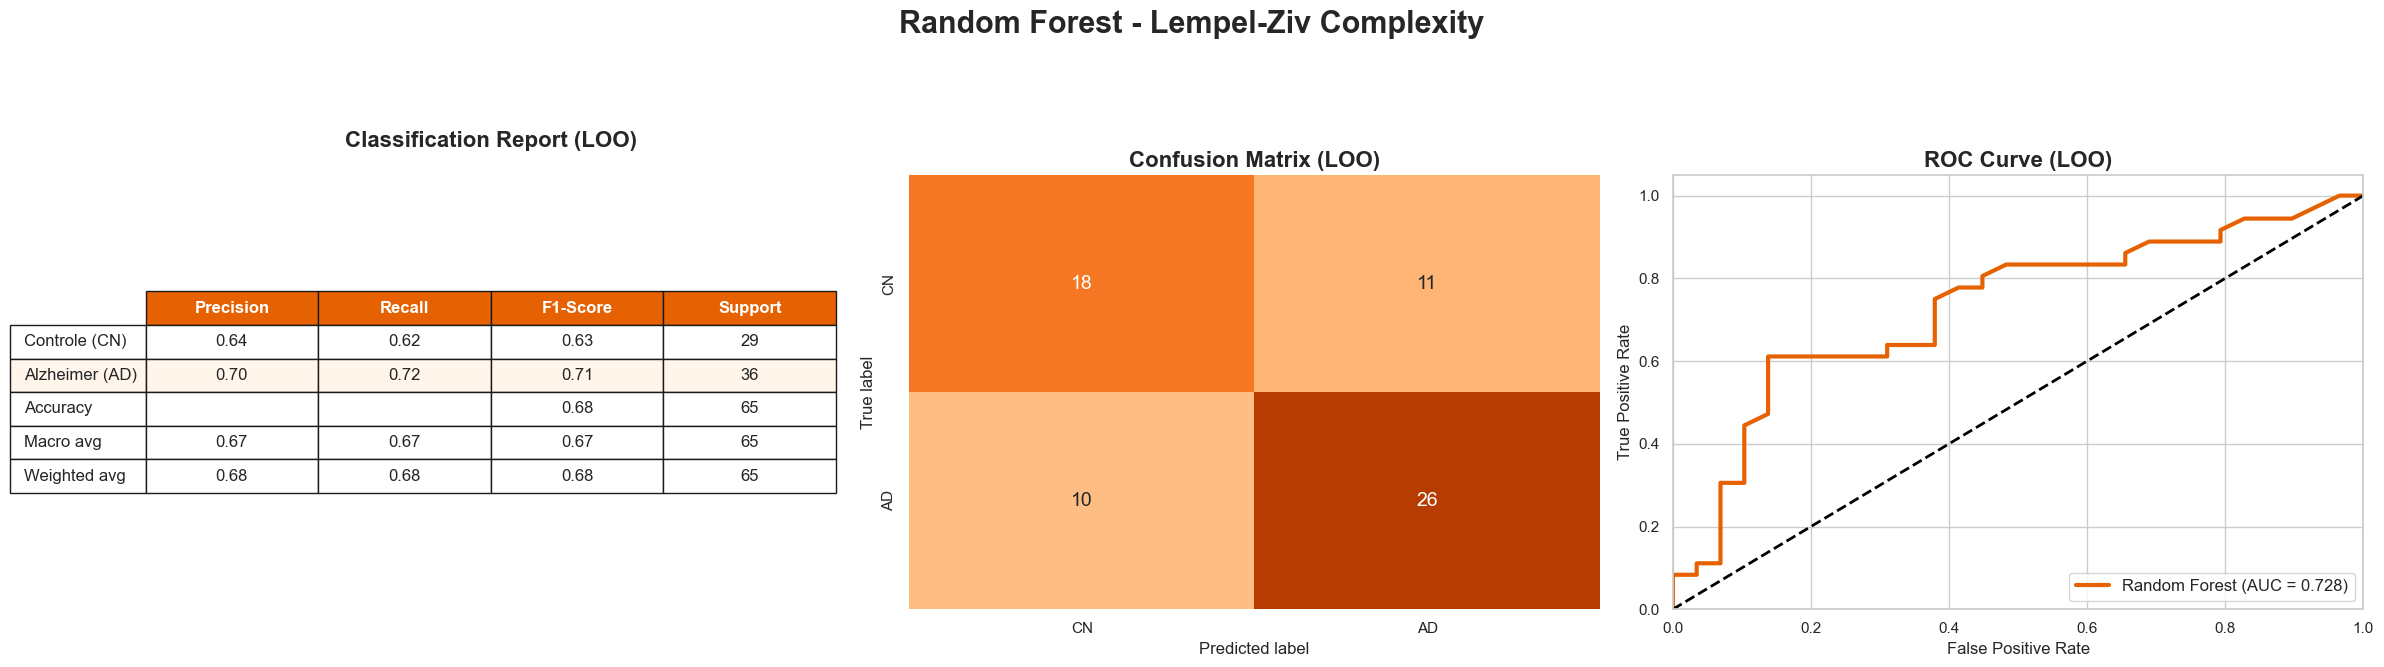

Dashboard salvo como: images\dashboard_Random_Forest_Lempel-Ziv_Complexity.png

Treinando Random Forest para: Phase-Amplitude Coupling...


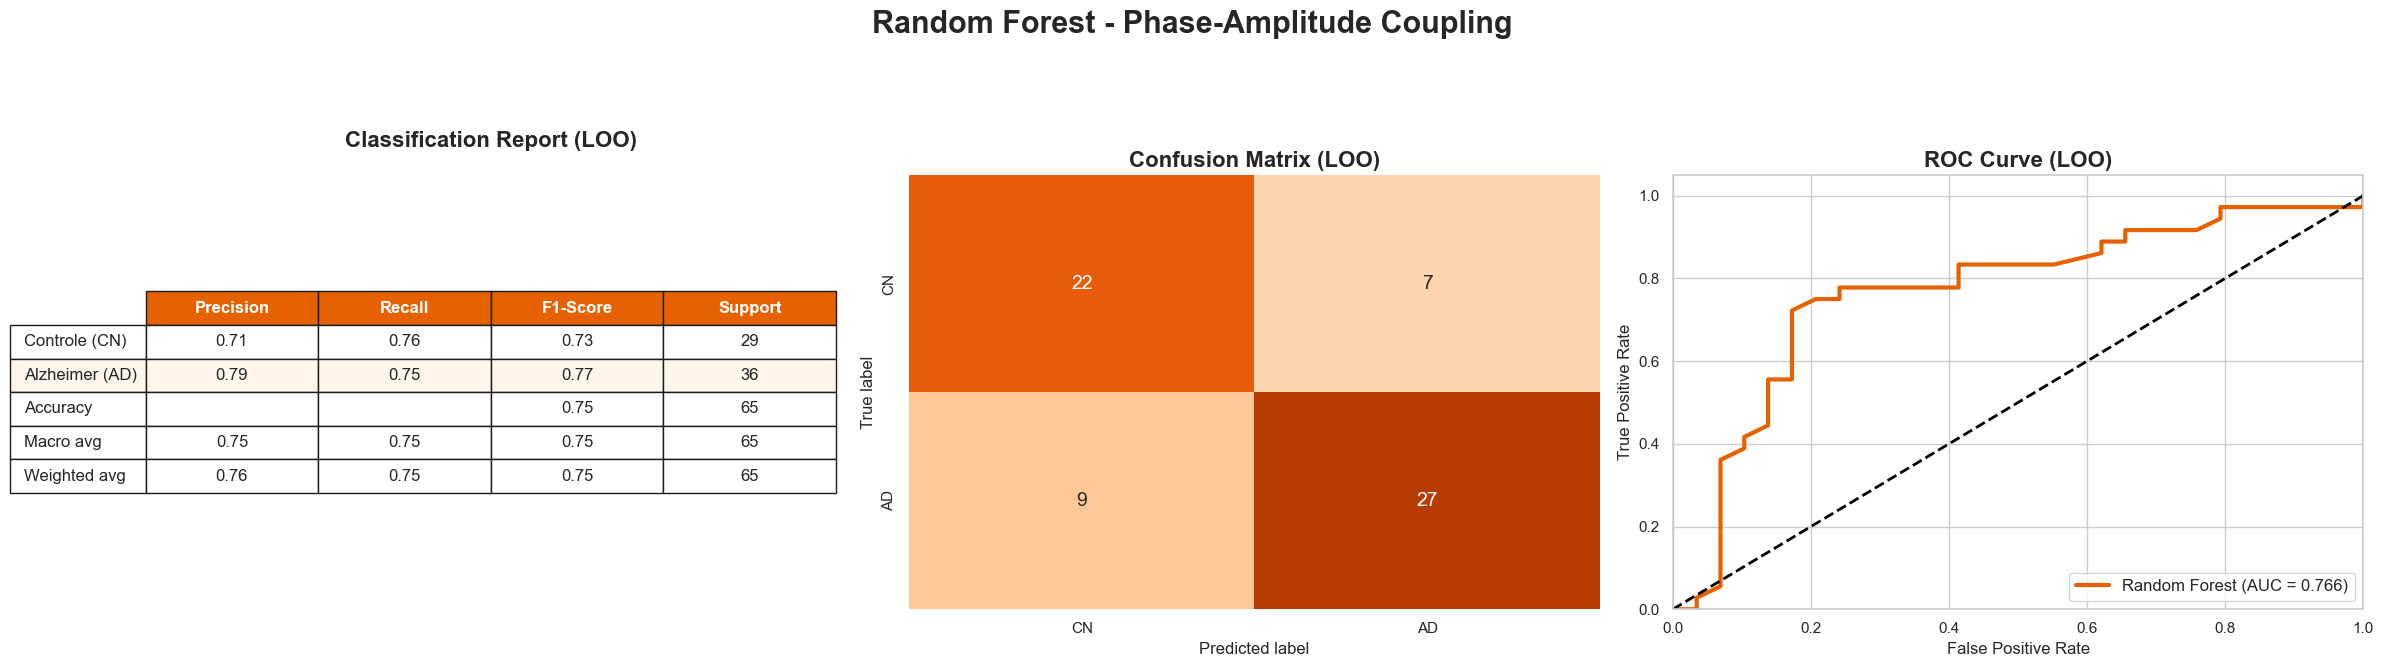

Dashboard salvo como: images\dashboard_Random_Forest_Phase-Amplitude_Coupling.png

Treinando Random Forest para: Kuramoto Order...


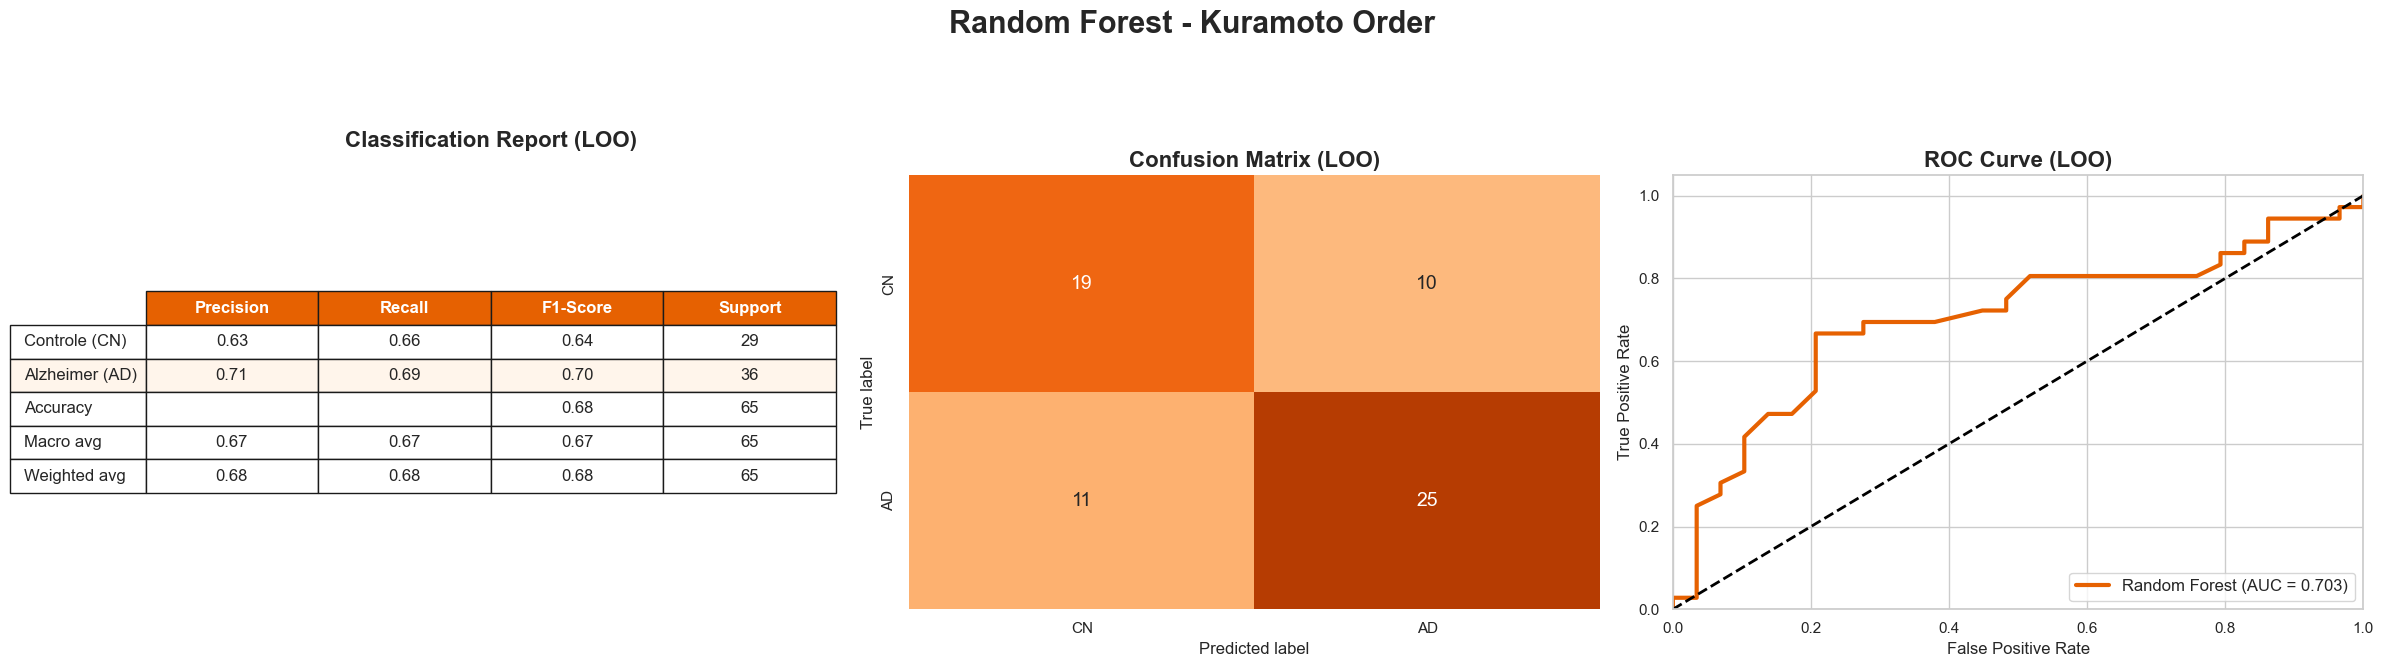

Dashboard salvo como: images\dashboard_Random_Forest_Kuramoto_Order.png

Treinando Random Forest para: Mutual Information...


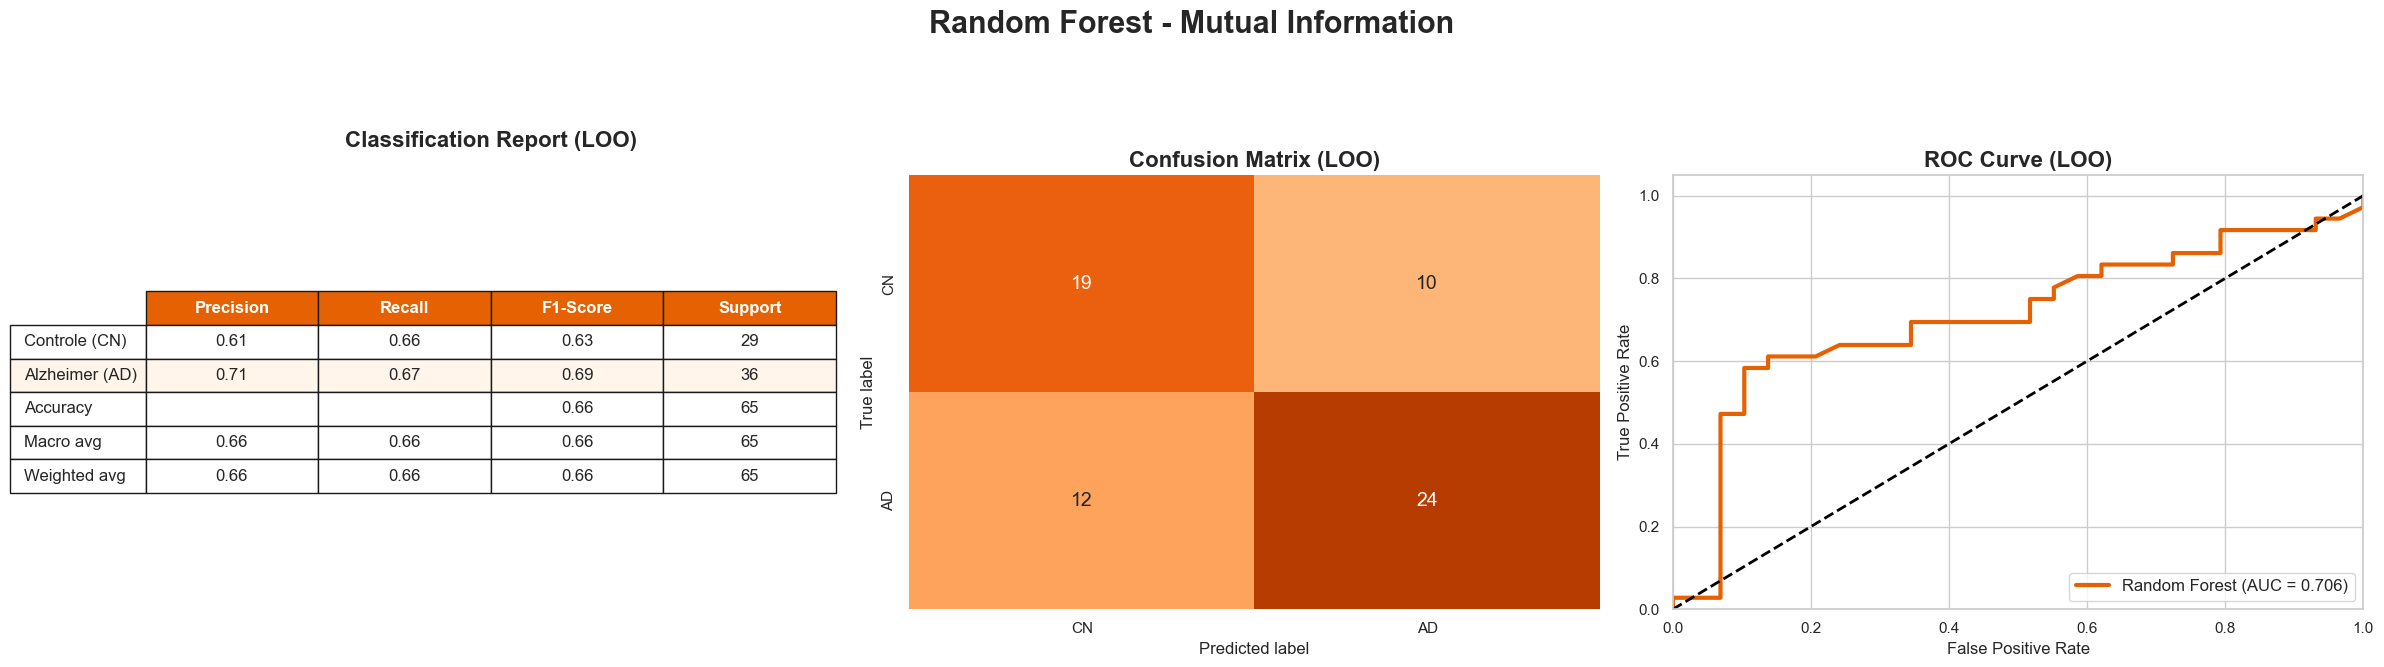

Dashboard salvo como: images\dashboard_Random_Forest_Mutual_Information.png

Treinando Random Forest para: Assinatura Completa (Multivariado)...


c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


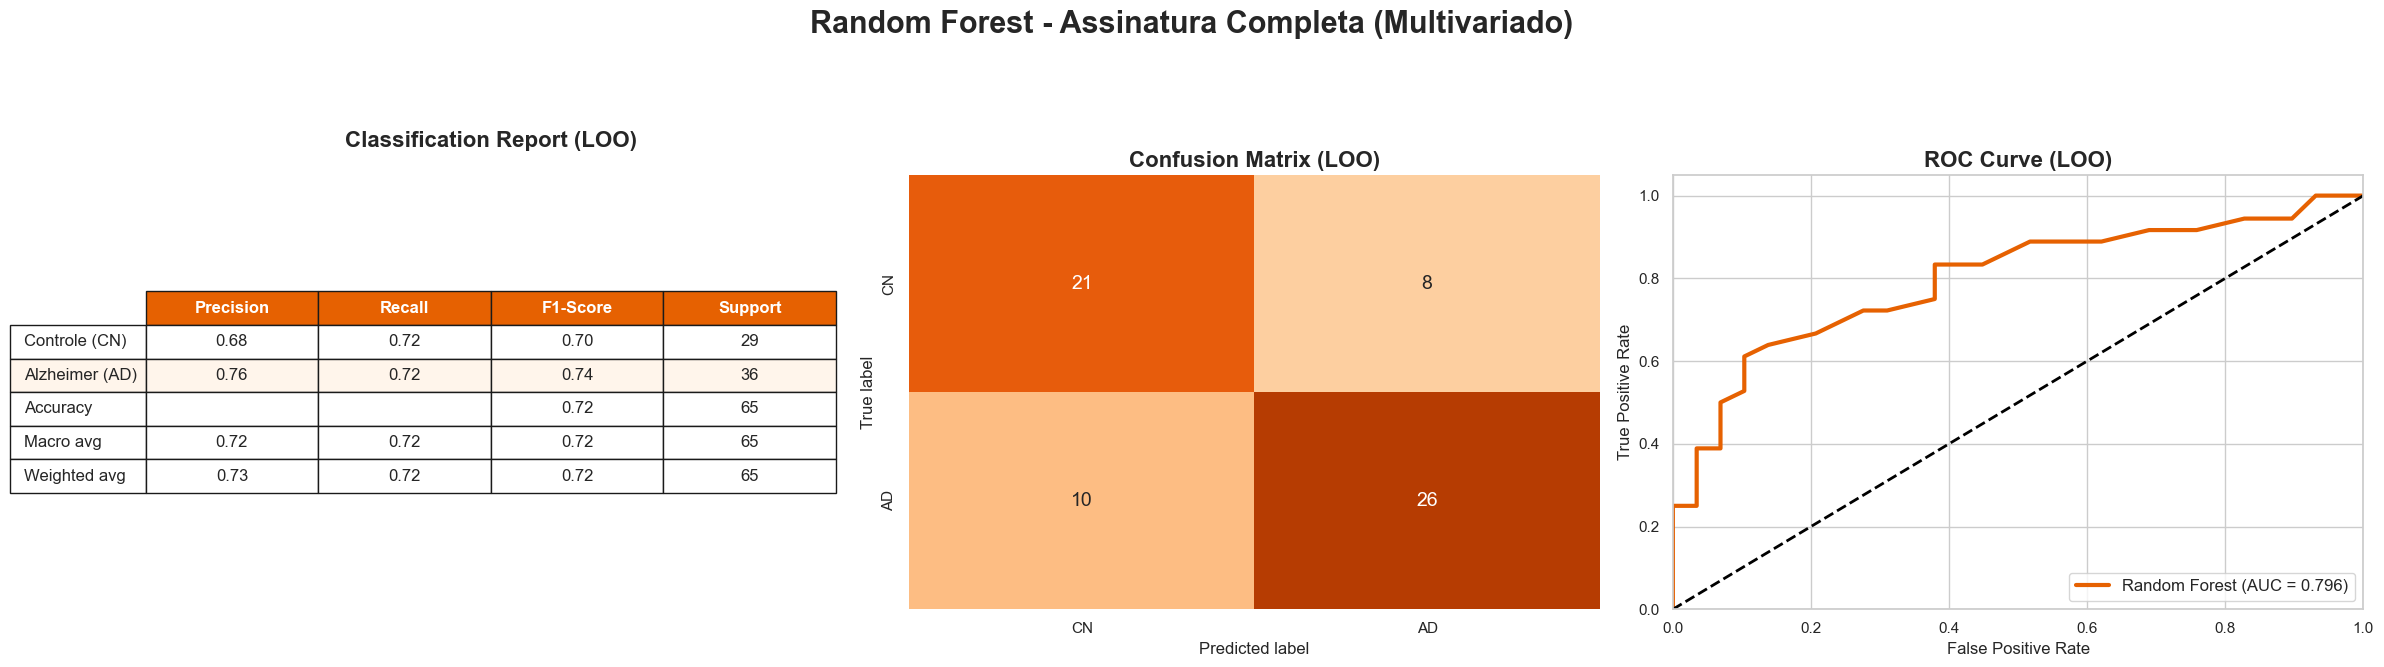

Dashboard salvo como: images\dashboard_Random_Forest_Assinatura_Completa_(Multivariado).png

--- TABELA DE COMPARAÇÃO GERAL ---


,Modelo,Categoria,Accuracy,Sensibilidade,Especificidade,F1,AUC
0,Random Forest,Baseline (RBP),0.6000,0.5278,0.6897,0.5938,0.6734
1,Random Forest,Mean Frequency,0.6000,0.6667,0.5172,0.6486,0.6236
2,Random Forest,Lempel-Ziv Complexity,0.6769,0.7222,0.6207,0.7123,0.7284
3,Random Forest,Phase-Amplitude Coupling,0.7538,0.7500,0.7586,0.7714,0.7658
4,Random Forest,Kuramoto Order,0.6769,0.6944,0.6552,0.7042,0.7026
5,Random Forest,Mutual Information,0.6615,0.6667,0.6552,0.6857,0.7064
6,Random Forest,Assinatura Completa (Multivariado),0.7231,0.7222,0.7241,0.7429,0.7960


In [34]:
# Carrega o dataset final
df = pd.read_csv('eeg_features_baseline_data.csv')


# MAPEAMENTO DOS GRUPOS DE FEATURES (Por Banda/Par)
features_rbp = [
    'Delta_RBP', 'Theta_RBP', 'Alpha_RBP', 'Beta_RBP', 'Gamma_RBP'
]

features_freq = [
    'Delta_Mean_Freq', 'Theta_Mean_Freq', 'Alpha_Mean_Freq', 'Beta_Mean_Freq', 'Gamma_Mean_Freq'
]

features_lzc = [
    'Delta_LZC', 'Theta_LZC', 'Alpha_LZC', 'Beta_LZC', 'Gamma_LZC'
]

features_pac = [
    'PAC_Delta_Beta', 'PAC_Delta_Gamma', 
    'PAC_Theta_Beta', 'PAC_Theta_Gamma', 
    'PAC_Alpha_Beta', 'PAC_Alpha_Gamma'
]

features_dasm = [
    'DASM_Delta', 'DASM_Theta', 'DASM_Alpha', 'DASM_Beta', 'DASM_Gamma'
]

features_kuramoto = [
    'Kuramoto_Delta', 'Kuramoto_Theta', 'Kuramoto_Alpha', 'Kuramoto_Beta', 'Kuramoto_Gamma'
]

features_mi = [
    'MI_Delta', 'MI_Theta', 'MI_Alpha', 'MI_Beta', 'MI_Gamma'
]

# Unificando todas as métricas para o teste final
features_todas = (features_rbp + features_freq + features_lzc + 
                  features_pac + features_kuramoto + features_mi)

# TREINAMENTO E VALIDAÇÃO (Média das Épocas por Paciente)
print(f"Iniciando a bateria de testes com {len(df['Subject_ID'].unique())} pacientes...\n")

evaluate_feature(df, features_rbp, "Baseline (RBP)")
evaluate_feature(df, features_freq, "Mean Frequency")
evaluate_feature(df, features_lzc, "Lempel-Ziv Complexity")
evaluate_feature(df, features_pac, "Phase-Amplitude Coupling")
evaluate_feature(df, features_kuramoto, "Kuramoto Order")
evaluate_feature(df, features_mi, "Mutual Information")

evaluate_feature(df, features_todas, "Assinatura Completa (Multivariado)")

# EXIBIÇÃO DA TABELA GLOBAL DE RESULTADOS
print("\n" + "="*50)
print("--- TABELA DE COMPARAÇÃO GERAL ---")
print("="*50)
df_resultados = pd.read_csv('resultados_modelos.csv')
display(df_resultados)

## SVM


Iniciando bateria SVM com 65 pacientes...

Treinando SVM (Linear) para: Baseline (RBP)...


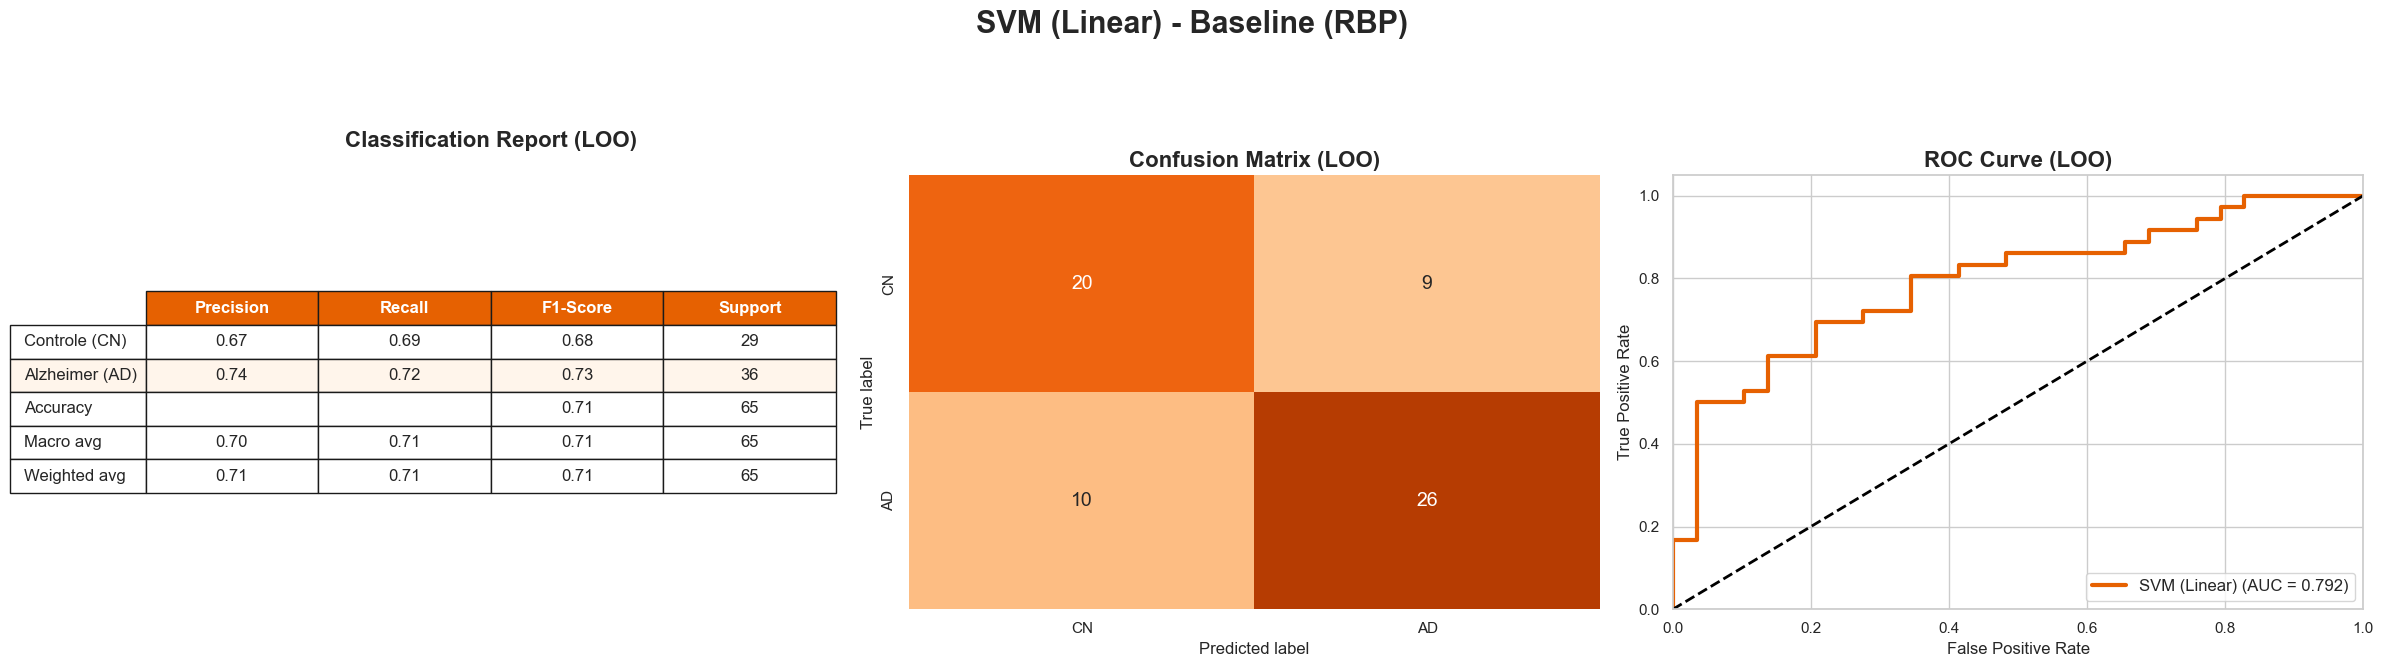

Dashboard salvo como: images\dashboard_SVM_(Linear)_Baseline_(RBP).png
Treinando SVM (Linear) para: Mean Frequency...


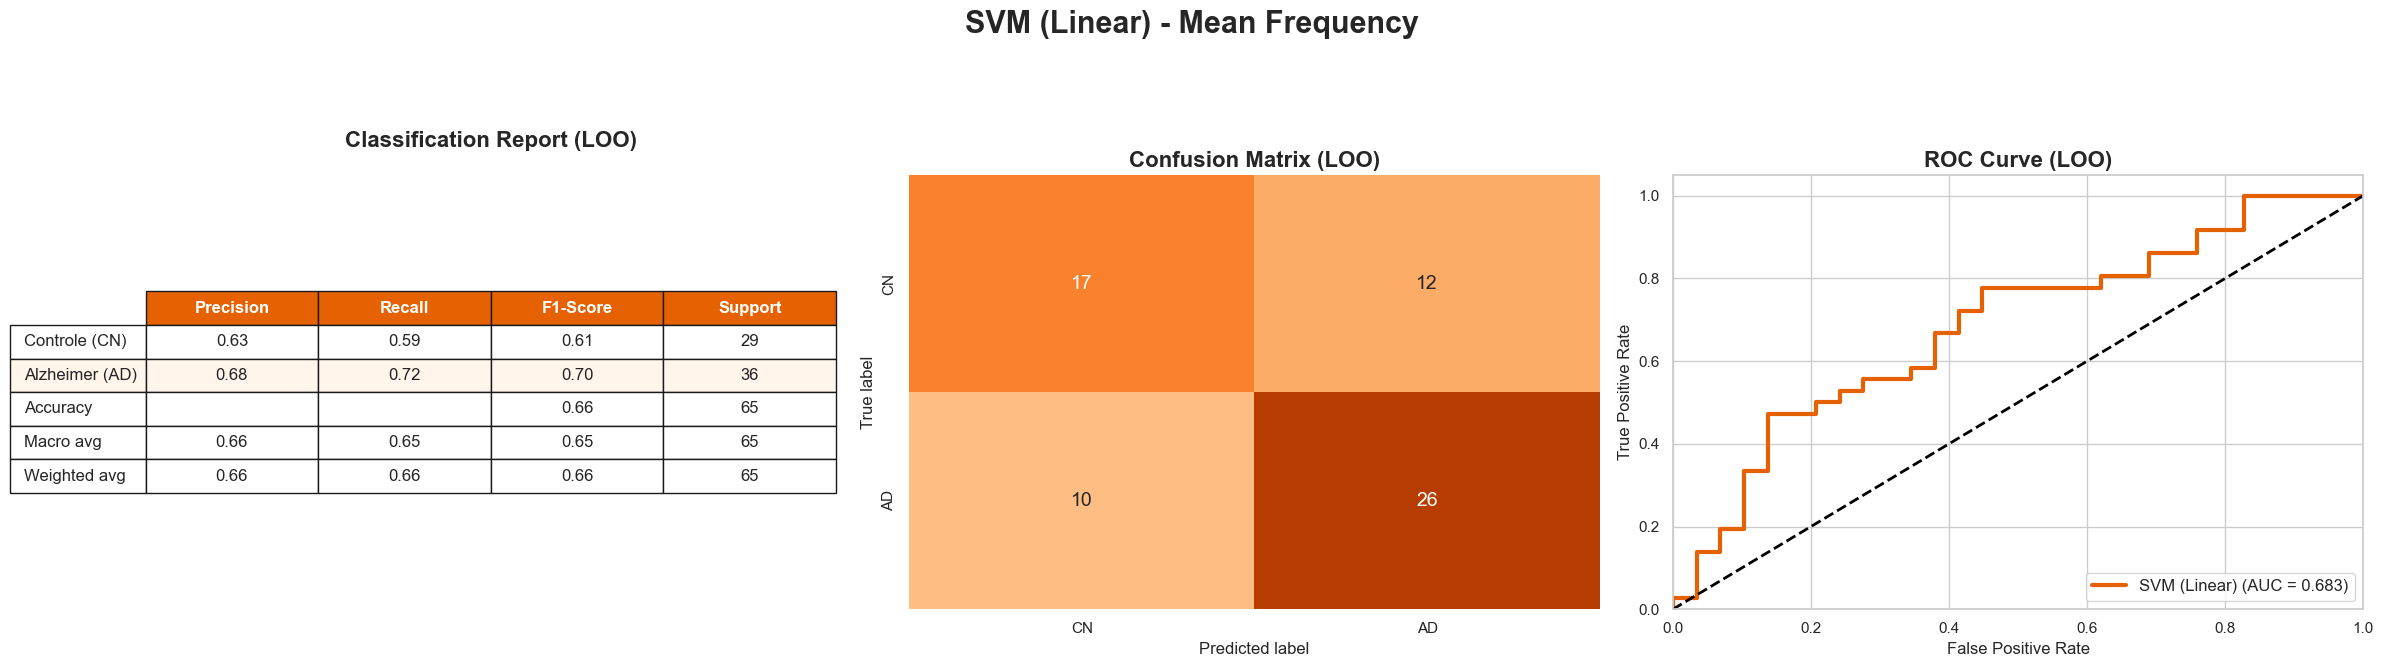

Dashboard salvo como: images\dashboard_SVM_(Linear)_Mean_Frequency.png
Treinando SVM (Linear) para: Lempel-Ziv Complexity...


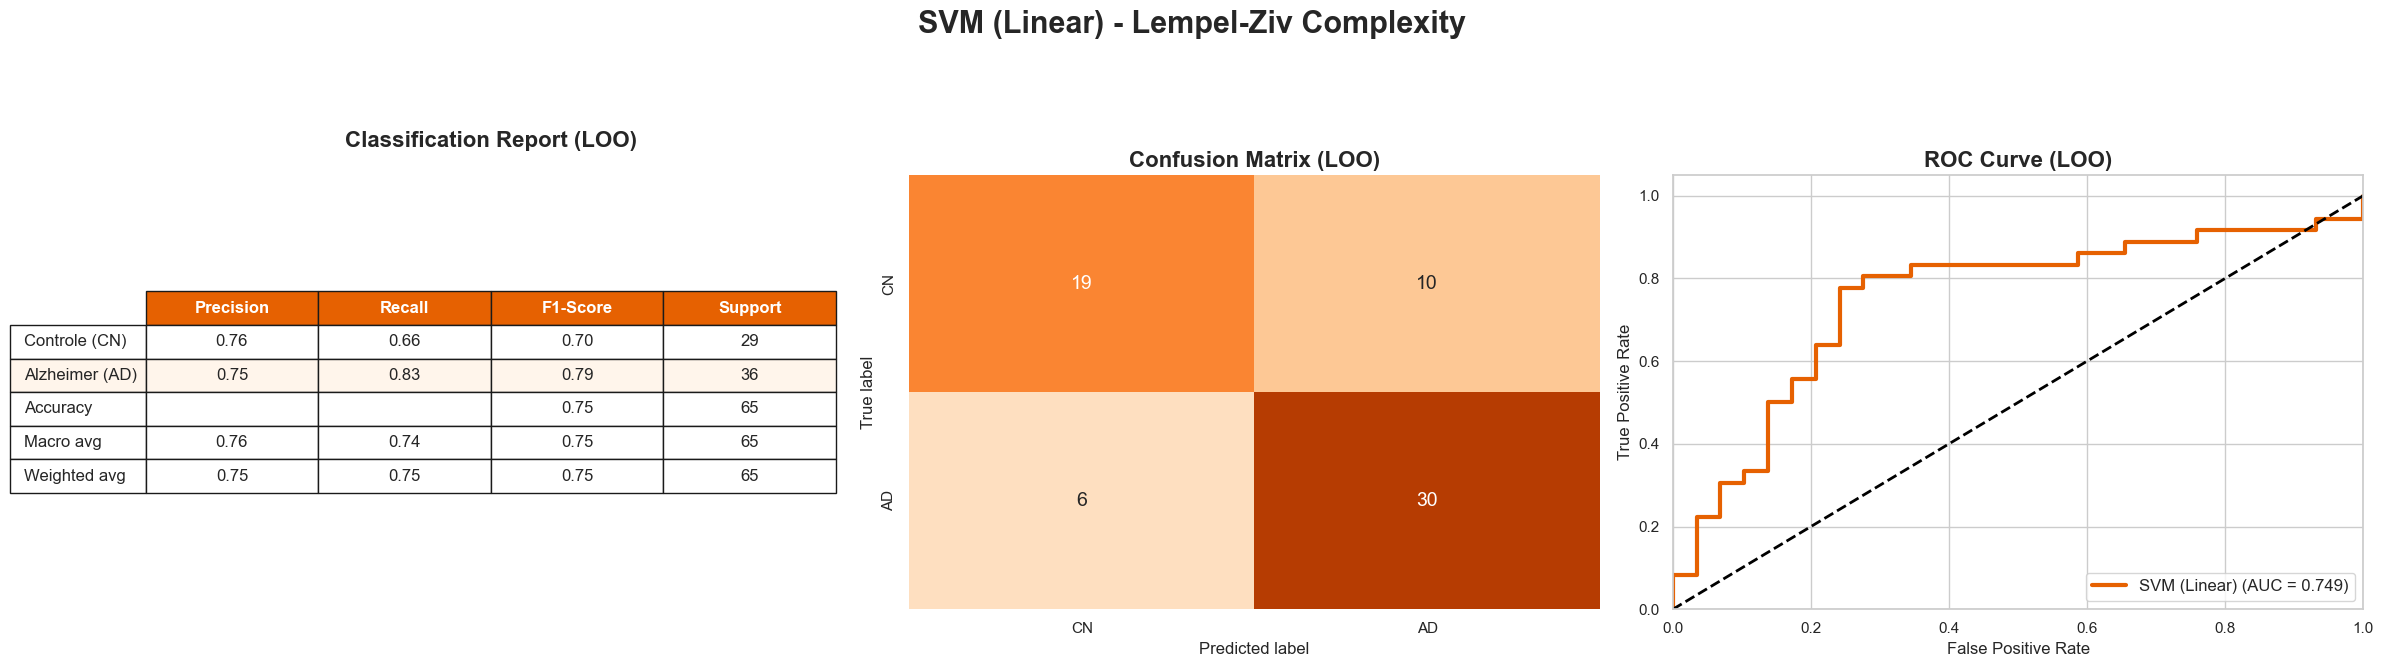

Dashboard salvo como: images\dashboard_SVM_(Linear)_Lempel-Ziv_Complexity.png
Treinando SVM (Linear) para: Phase-Amplitude Coupling...


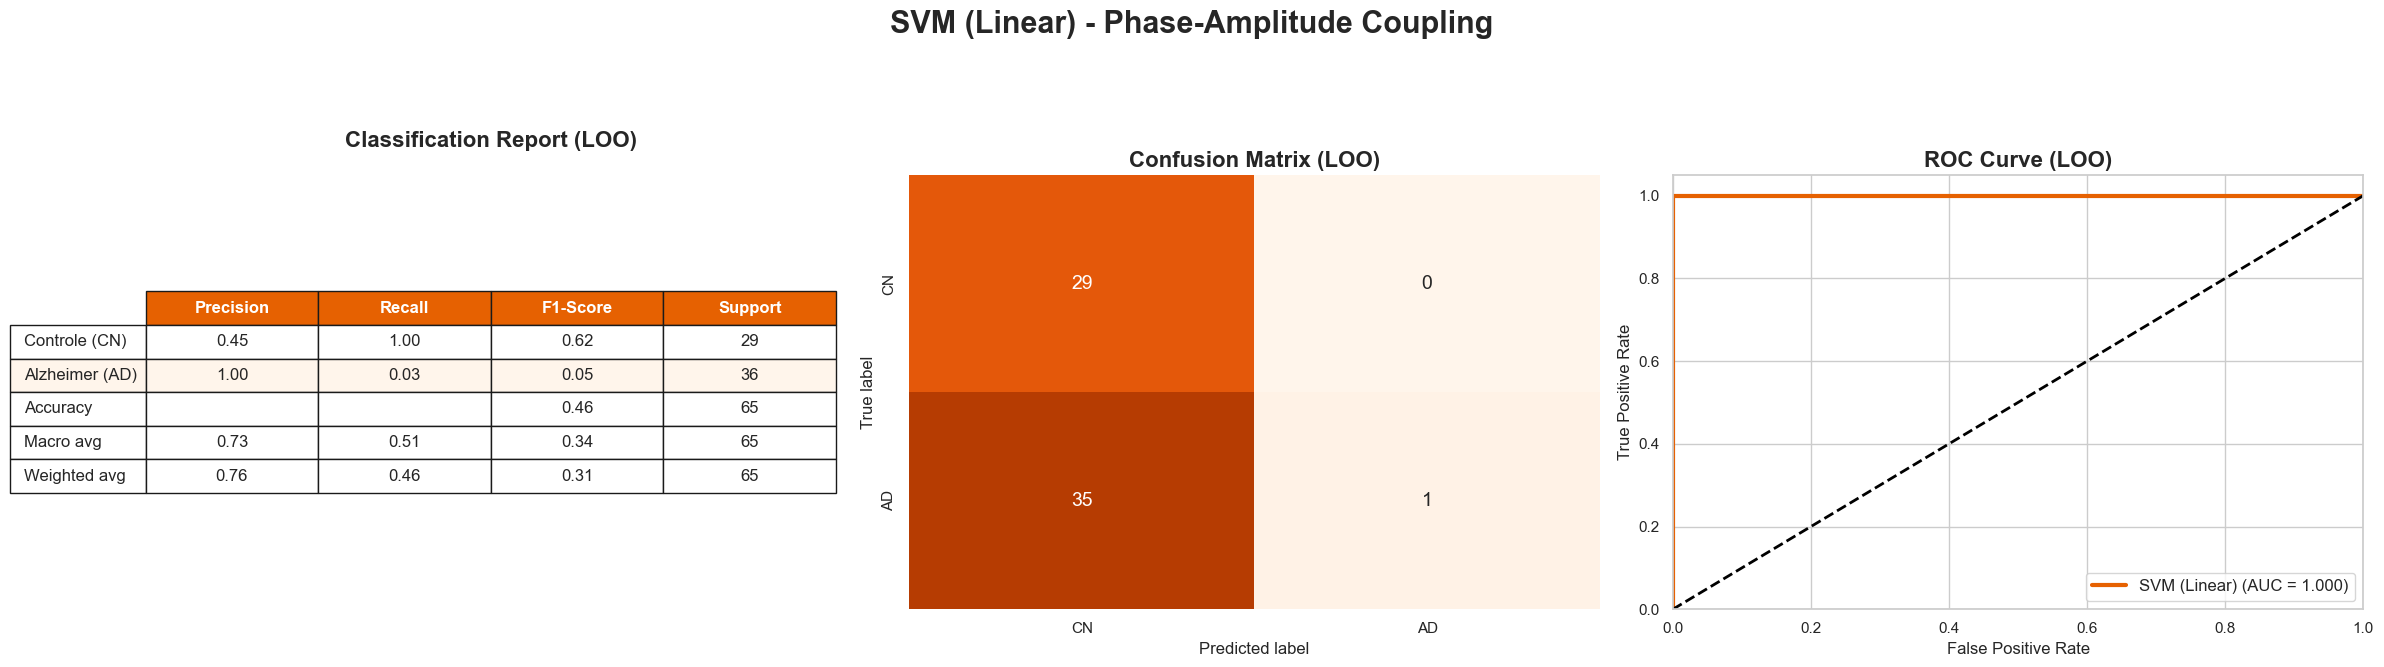

Dashboard salvo como: images\dashboard_SVM_(Linear)_Phase-Amplitude_Coupling.png
Treinando SVM (Linear) para: Kuramoto Order...


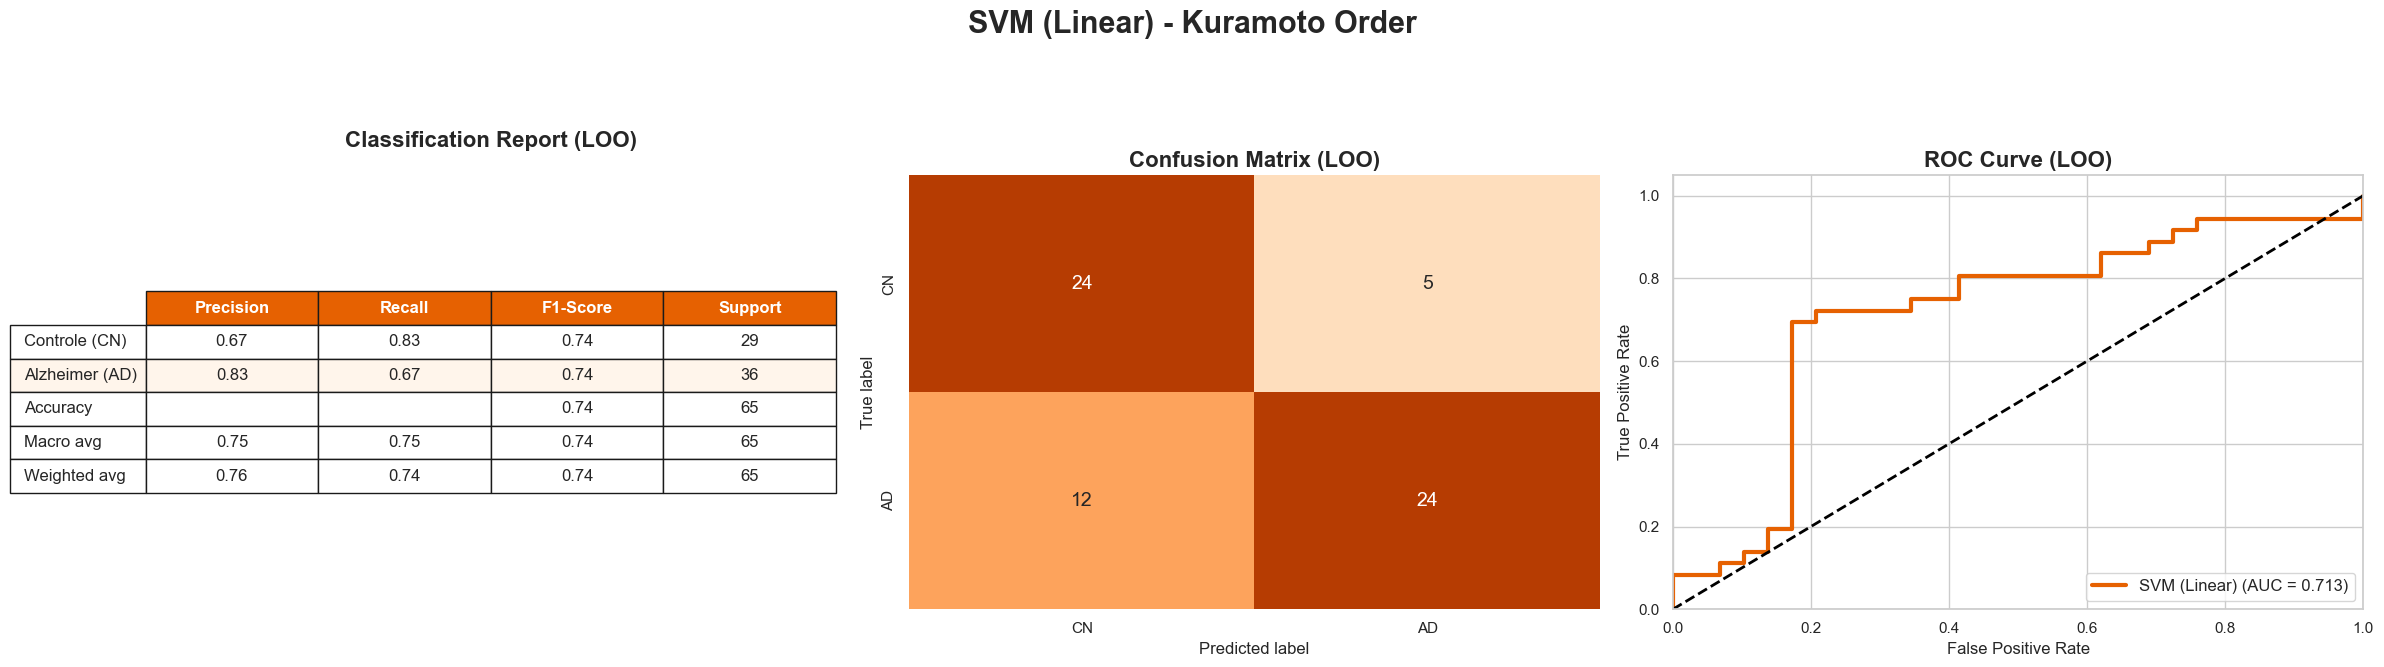

Dashboard salvo como: images\dashboard_SVM_(Linear)_Kuramoto_Order.png
Treinando SVM (Linear) para: Mutual Information...


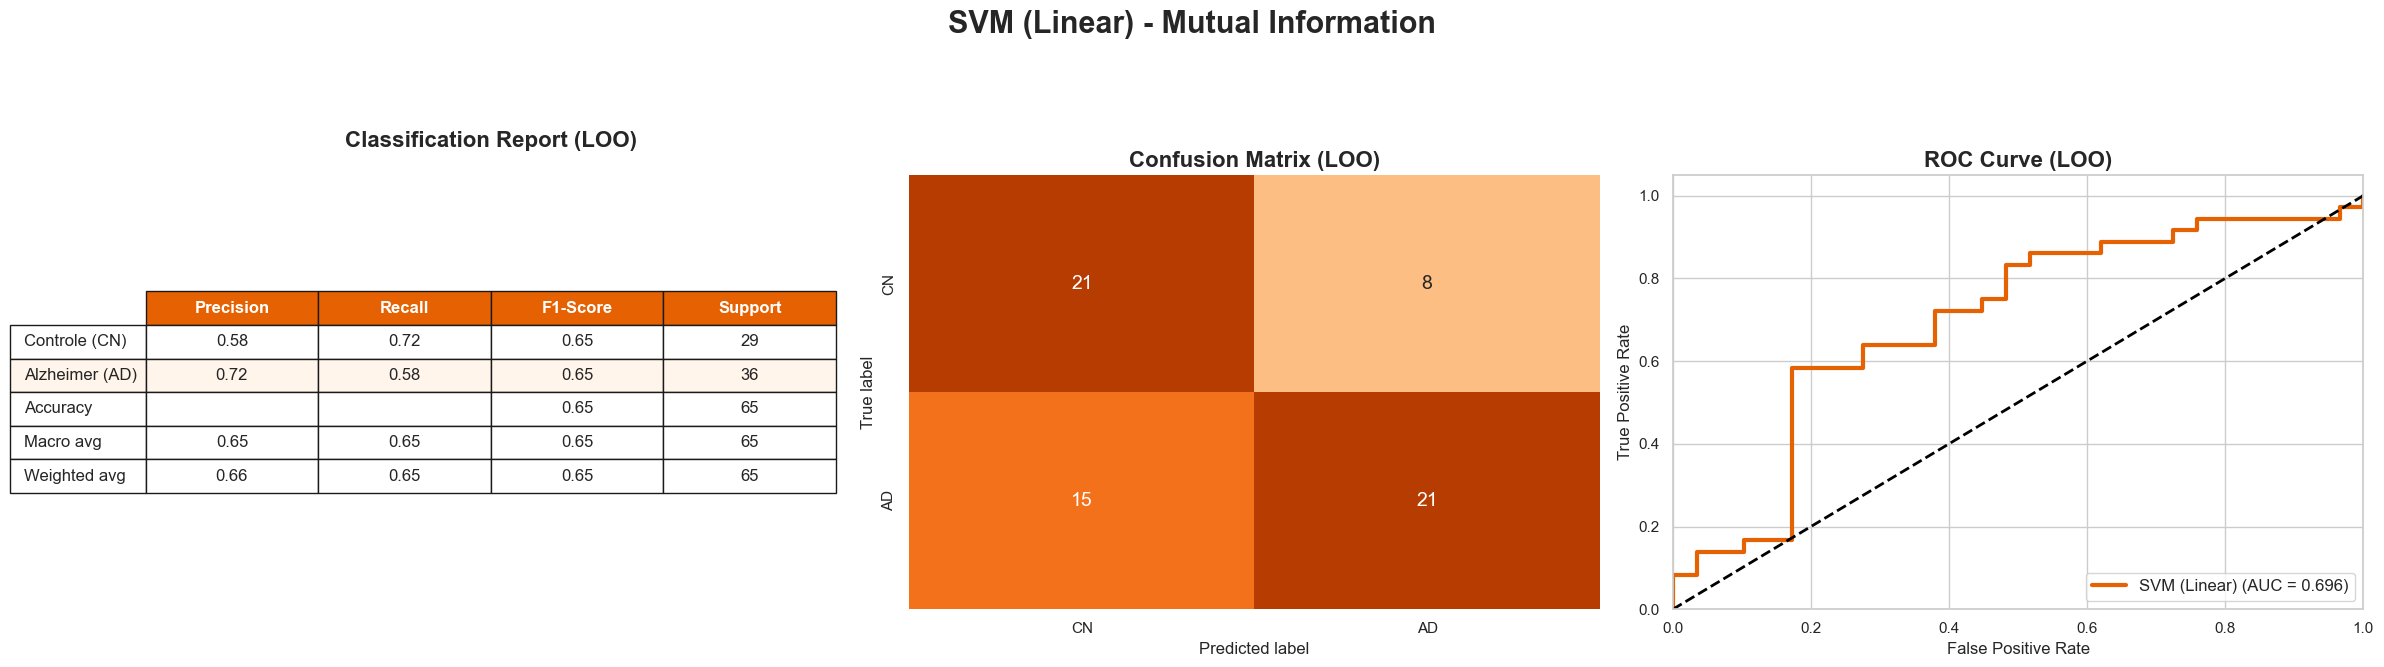

Dashboard salvo como: images\dashboard_SVM_(Linear)_Mutual_Information.png
Treinando SVM (Linear) para: Assinatura Completa (Multivariado)...


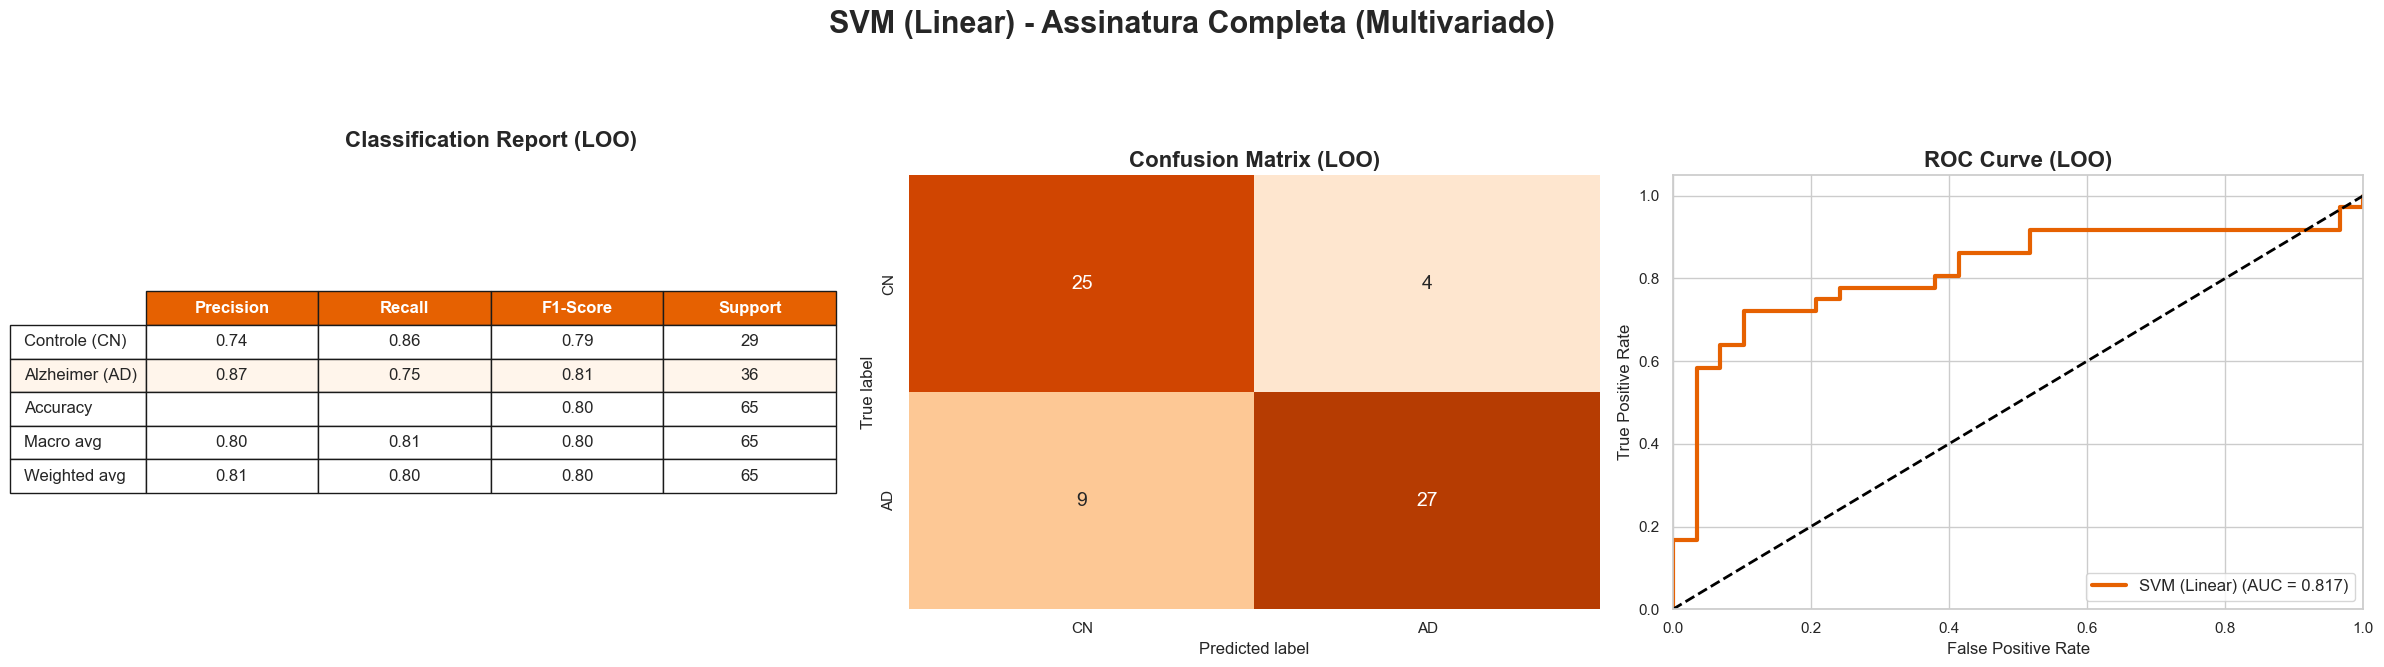

Dashboard salvo como: images\dashboard_SVM_(Linear)_Assinatura_Completa_(Multivariado).png

--- TABELA DE COMPARAÇÃO GERAL (INCLUINDO SVM) ---


,Modelo,Categoria,Accuracy,Sensibilidade,Especificidade,F1,AUC
0,Random Forest,Baseline (RBP),0.6000,0.5278,0.6897,0.5938,0.6734
1,Random Forest,Mean Frequency,0.6000,0.6667,0.5172,0.6486,0.6236
2,Random Forest,Lempel-Ziv Complexity,0.6769,0.7222,0.6207,0.7123,0.7284
3,Random Forest,Phase-Amplitude Coupling,0.7538,0.7500,0.7586,0.7714,0.7658
4,Random Forest,Kuramoto Order,0.6769,0.6944,0.6552,0.7042,0.7026
5,Random Forest,Mutual Information,0.6615,0.6667,0.6552,0.6857,0.7064
6,Random Forest,Assinatura Completa (Multivariado),0.7231,0.7222,0.7241,0.7429,0.7960
7,SVM (Linear),Baseline (RBP),0.7077,0.7222,0.6897,0.7324,0.7921
8,SVM (Linear),Mean Frequency,0.6615,0.7222,0.5862,0.7027,0.6830
9,SVM (Linear),Lempel-Ziv Complexity,0.7538,0.8333,0.6552,0.7895,0.7490


In [35]:
# FUNÇÃO DE AVALIAÇÃO ATUALIZADA (SVM + StandardScaler)
def evaluate_feature_svm(df, feature_cols, category_name, model_name="SVM (Linear)"):
    # Agrupa tirando a média por paciente
    df_grouped = df.groupby(['Subject_ID', 'Group'], as_index=False)[feature_cols].mean()
    
    X = df_grouped[feature_cols].values
    y = np.where(df_grouped['Group'] == 'A', 1, 0)
    groups = df_grouped['Subject_ID'].values
    
    clf = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)
    loso = LeaveOneGroupOut()
    
    all_y_true = []
    all_y_pred = []
    all_y_prob = []
    
    print(f"Treinando {model_name} para: {category_name}...")
    
    for train_idx, test_idx in loso.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 1. TRATAMENTO DE NaNs (Substitui valores nulos pela mediana do treino)
        imputer = SimpleImputer(strategy='median')
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
        
        # 2. NORMALIZAÇÃO OBRIGATÓRIA PARA O SVM
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_imputed)
        X_test_scaled = scaler.transform(X_test_imputed)
        
        # 3. Treina e prevê com os dados limpos e na mesma escala
        clf.fit(X_train_scaled, y_train)
        
        all_y_true.append(y_test[0])
        all_y_pred.append(clf.predict(X_test_scaled)[0])
        all_y_prob.append(clf.predict_proba(X_test_scaled)[0, 1])
        
    save_results(model_name, category_name, all_y_true, all_y_pred, all_y_prob)
    plot_dashboard(model_name, all_y_true, all_y_pred, all_y_prob, category_name)


# DEFINIÇÃO DAS FEATURES E BATERIA DE TESTES
df = pd.read_csv('eeg_features_baseline_data.csv')

features_rbp = ['Delta_RBP', 'Theta_RBP', 'Alpha_RBP', 'Beta_RBP', 'Gamma_RBP']
features_freq = ['Delta_Mean_Freq', 'Theta_Mean_Freq', 'Alpha_Mean_Freq', 'Beta_Mean_Freq', 'Gamma_Mean_Freq']
features_lzc = ['Delta_LZC', 'Theta_LZC', 'Alpha_LZC', 'Beta_LZC', 'Gamma_LZC']
features_pac = ['PAC_Delta_Beta', 'PAC_Delta_Gamma', 'PAC_Theta_Beta', 'PAC_Theta_Gamma', 'PAC_Alpha_Beta', 'PAC_Alpha_Gamma']
features_kuramoto = ['Kuramoto_Delta', 'Kuramoto_Theta', 'Kuramoto_Alpha', 'Kuramoto_Beta', 'Kuramoto_Gamma']
features_mi = ['MI_Delta', 'MI_Theta', 'MI_Alpha', 'MI_Beta', 'MI_Gamma']

features_todas = (features_rbp + features_freq + features_lzc + 
                  features_pac + features_kuramoto + features_mi)

print(f"\nIniciando bateria SVM com {len(df['Subject_ID'].unique())} pacientes...\n")

evaluate_feature_svm(df, features_rbp, "Baseline (RBP)")
evaluate_feature_svm(df, features_freq, "Mean Frequency")
evaluate_feature_svm(df, features_lzc, "Lempel-Ziv Complexity")
evaluate_feature_svm(df, features_pac, "Phase-Amplitude Coupling")
evaluate_feature_svm(df, features_kuramoto, "Kuramoto Order")
evaluate_feature_svm(df, features_mi, "Mutual Information")

# O super modelo com 36 variáveis
evaluate_feature_svm(df, features_todas, "Assinatura Completa (Multivariado)")

# RESULTADOS FINAIS
print("\n" + "="*50)
print("--- TABELA DE COMPARAÇÃO GERAL (INCLUINDO SVM) ---")
print("="*50)
df_resultados = pd.read_csv('resultados_modelos.csv')
display(df_resultados)

## XGBoost


Iniciando bateria XGBoost com 65 pacientes...

Treinando XGBoost para: Baseline (RBP)...


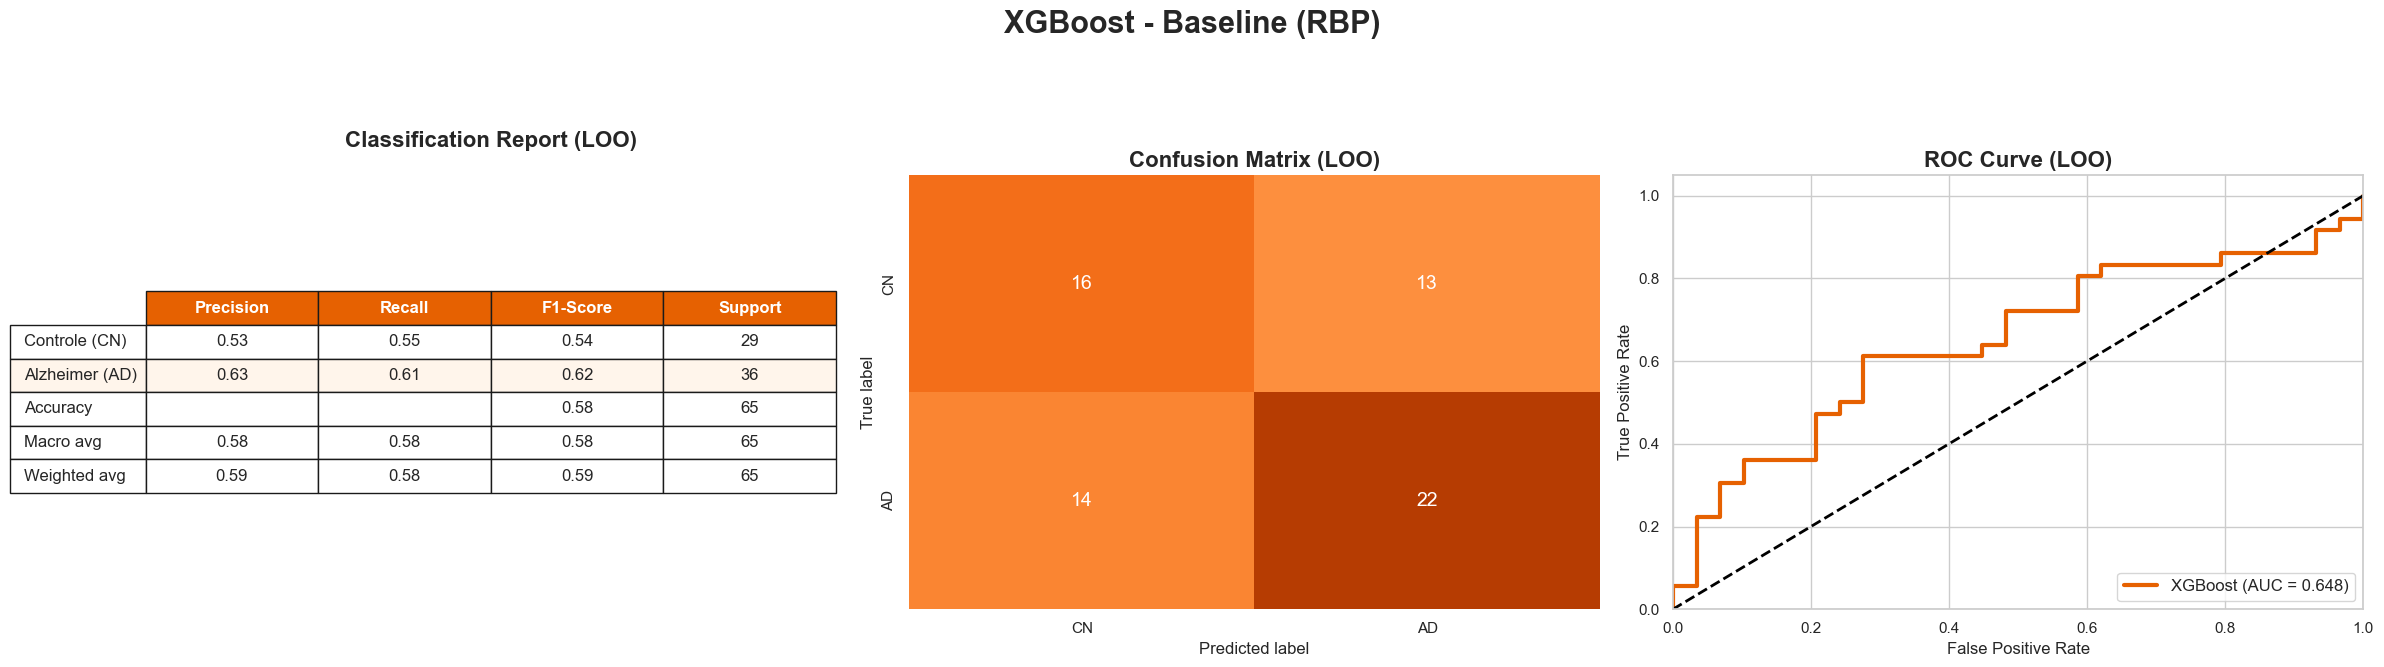

Dashboard salvo como: images\dashboard_XGBoost_Baseline_(RBP).png
Treinando XGBoost para: Mean Frequency...


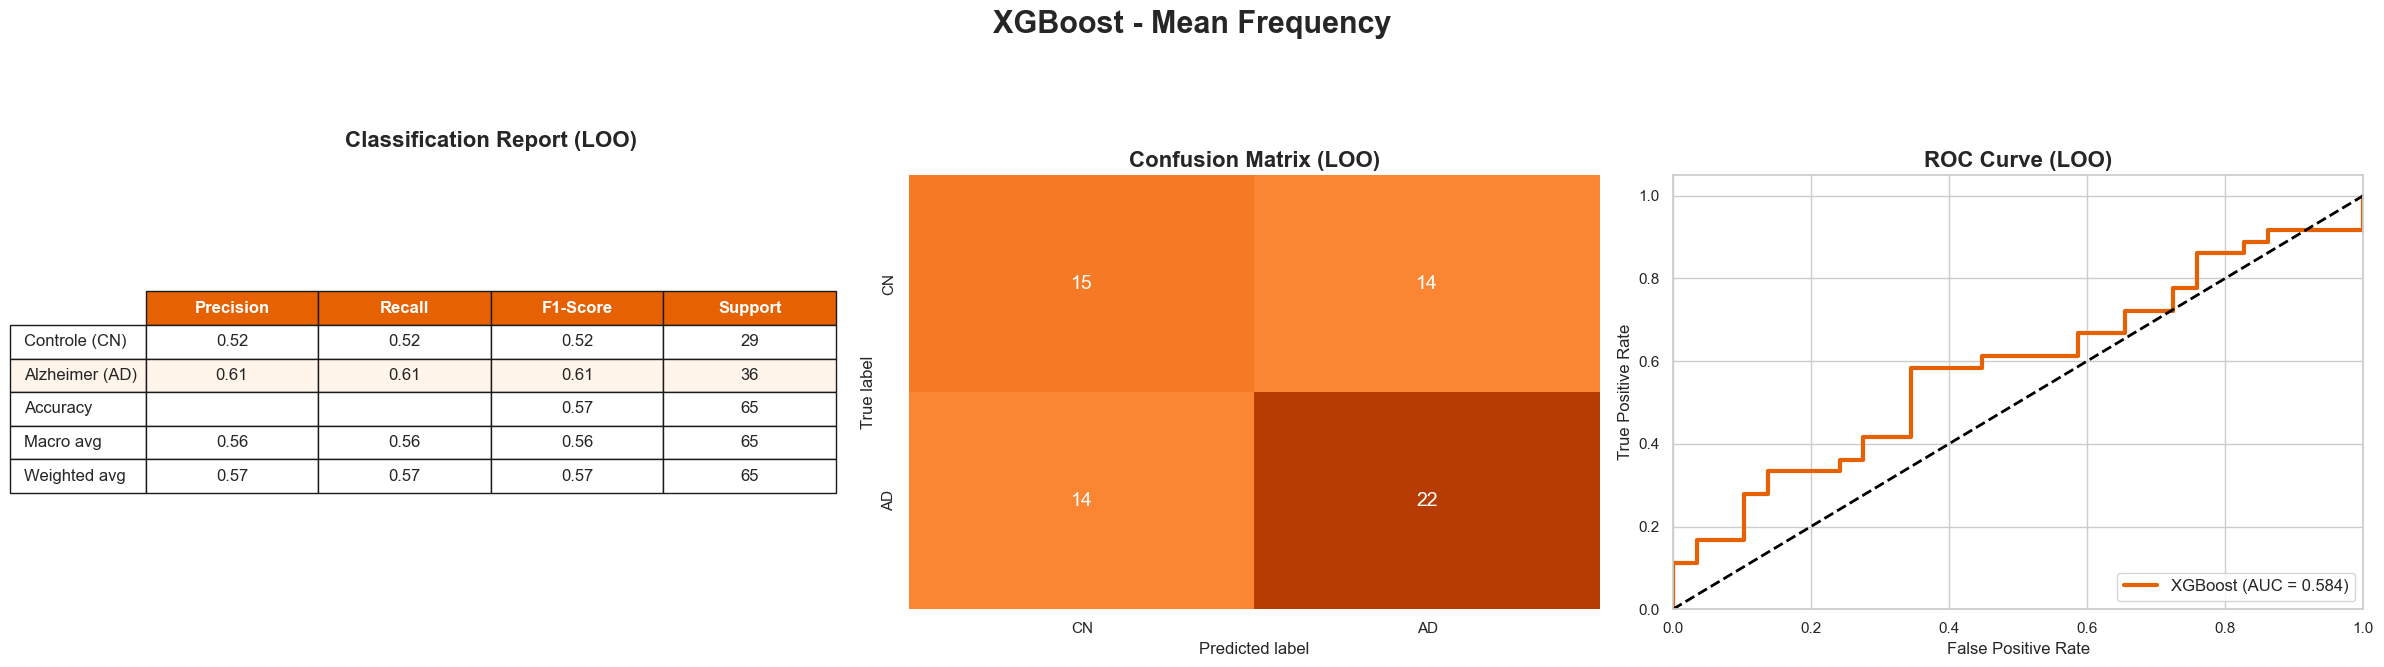

Dashboard salvo como: images\dashboard_XGBoost_Mean_Frequency.png
Treinando XGBoost para: Lempel-Ziv Complexity...


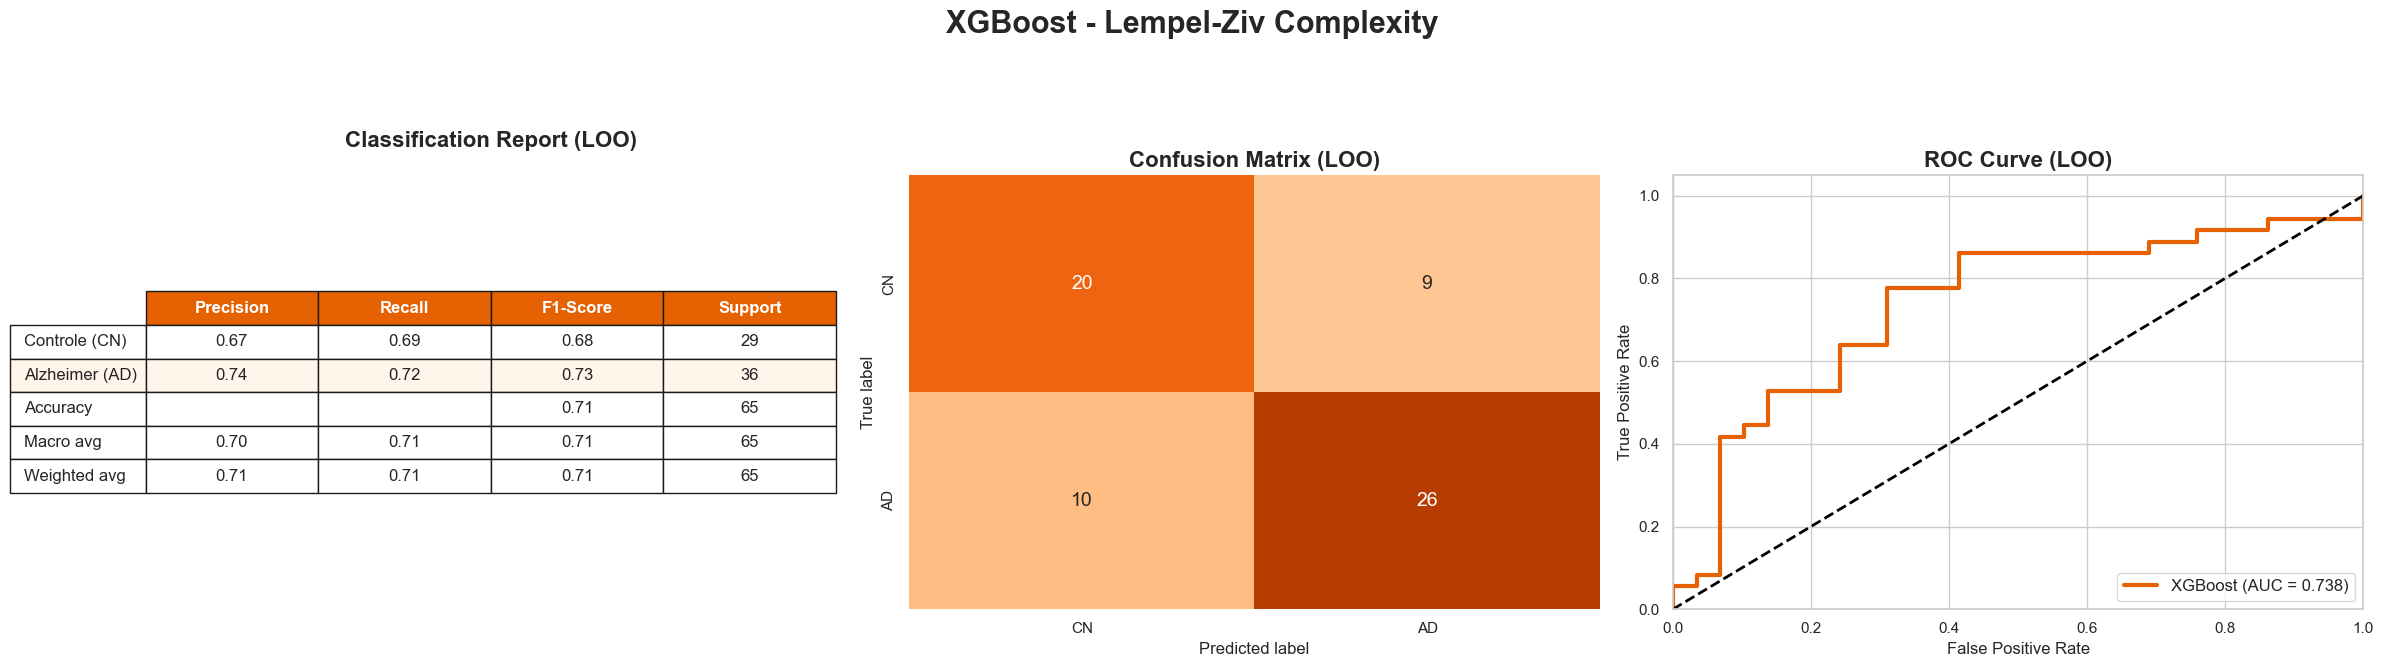

Dashboard salvo como: images\dashboard_XGBoost_Lempel-Ziv_Complexity.png
Treinando XGBoost para: Phase-Amplitude Coupling...


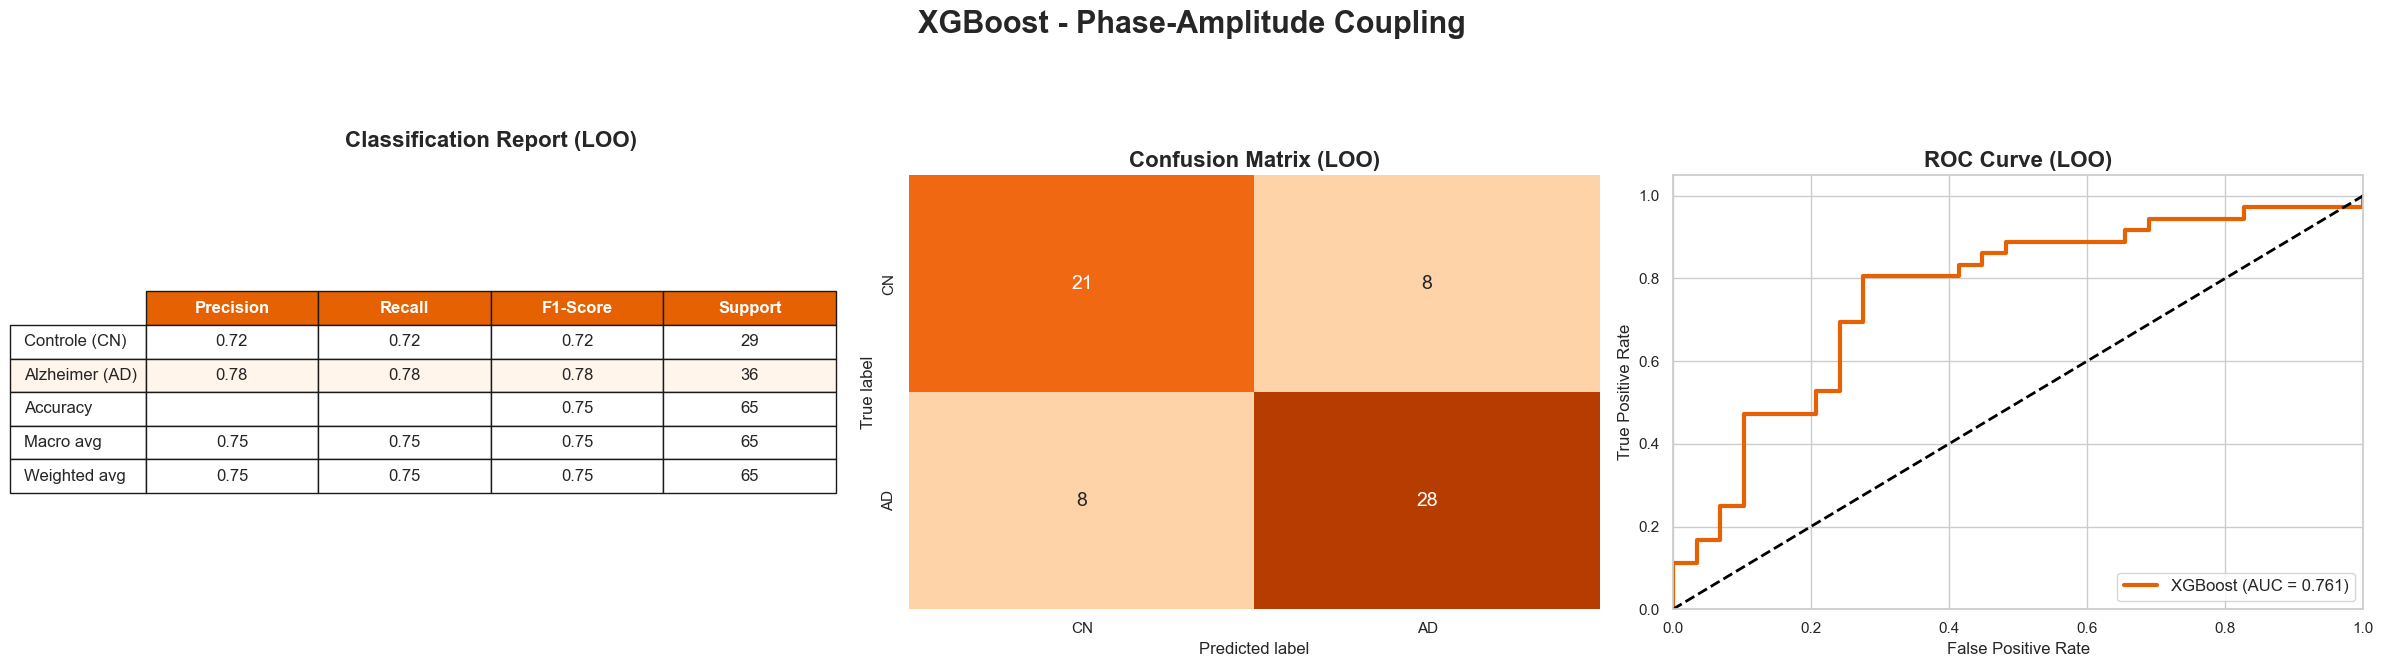

Dashboard salvo como: images\dashboard_XGBoost_Phase-Amplitude_Coupling.png
Treinando XGBoost para: Kuramoto Order...


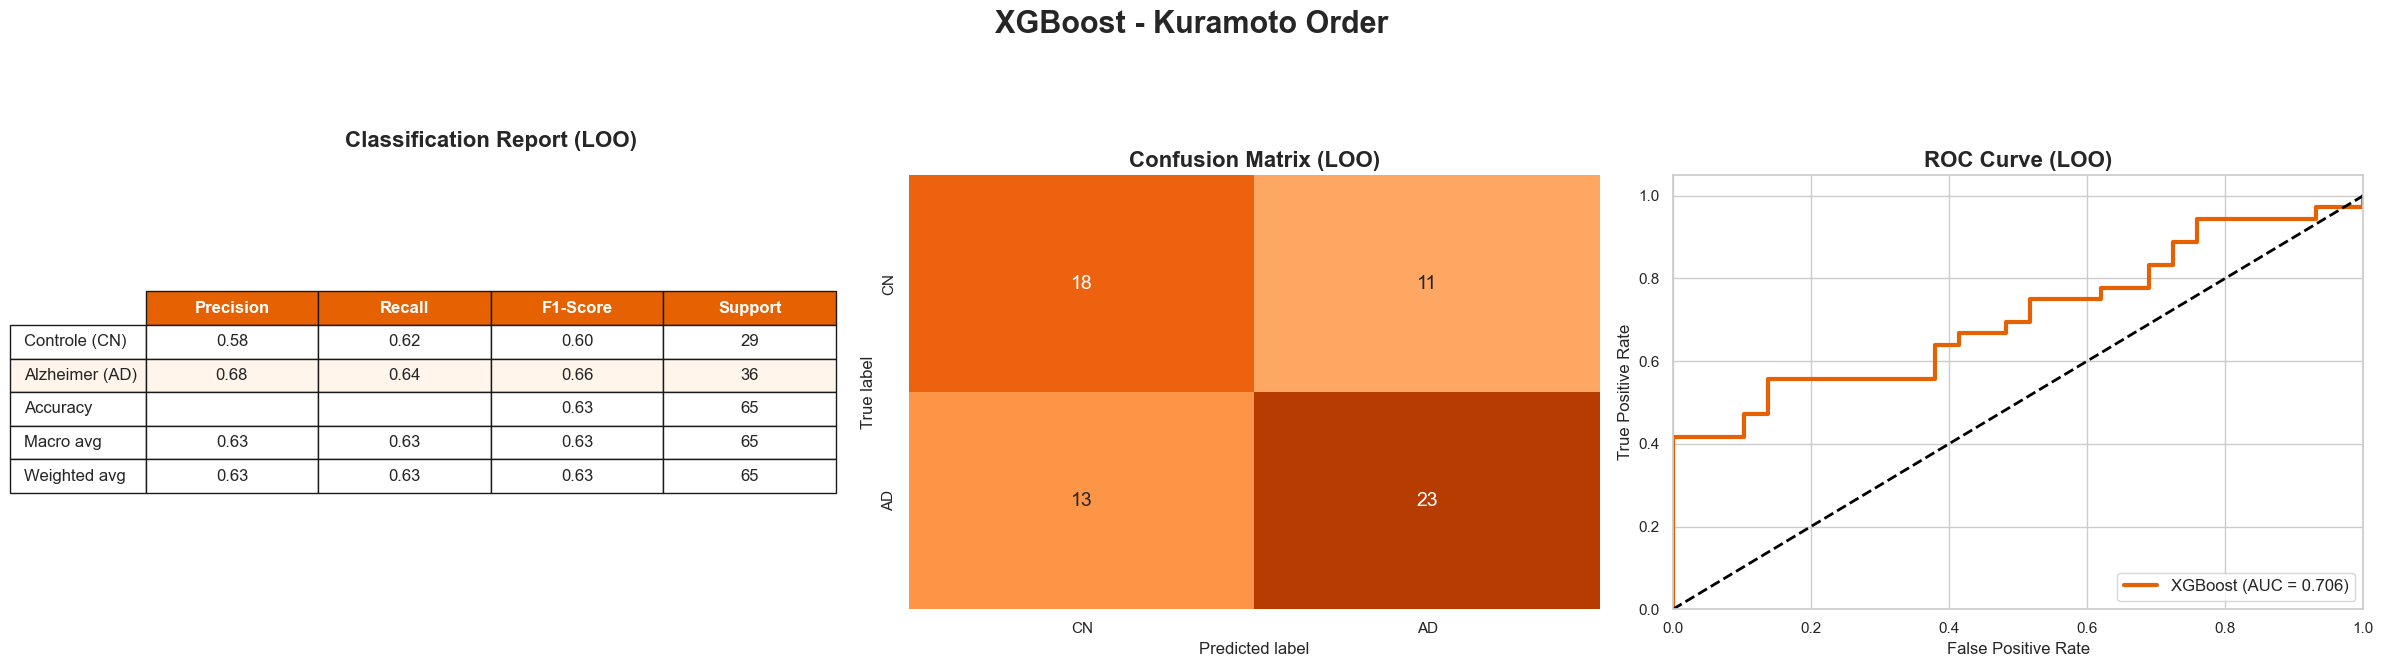

Dashboard salvo como: images\dashboard_XGBoost_Kuramoto_Order.png
Treinando XGBoost para: Mutual Information...


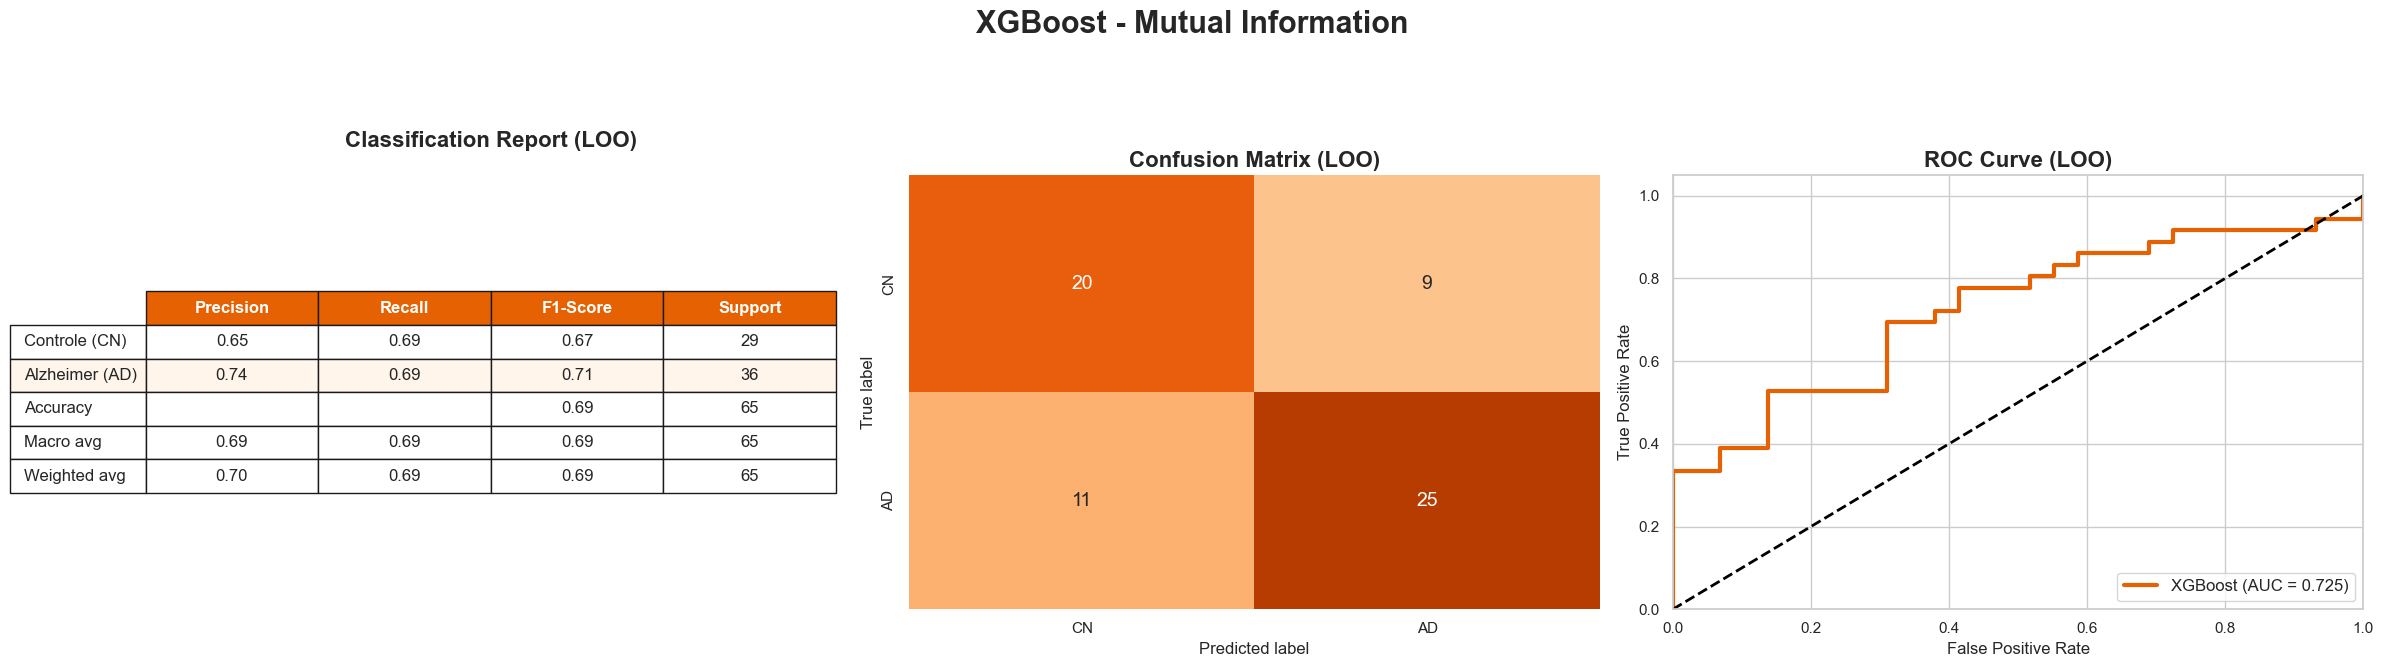

Dashboard salvo como: images\dashboard_XGBoost_Mutual_Information.png
Treinando XGBoost para: Assinatura Completa (Multivariado)...


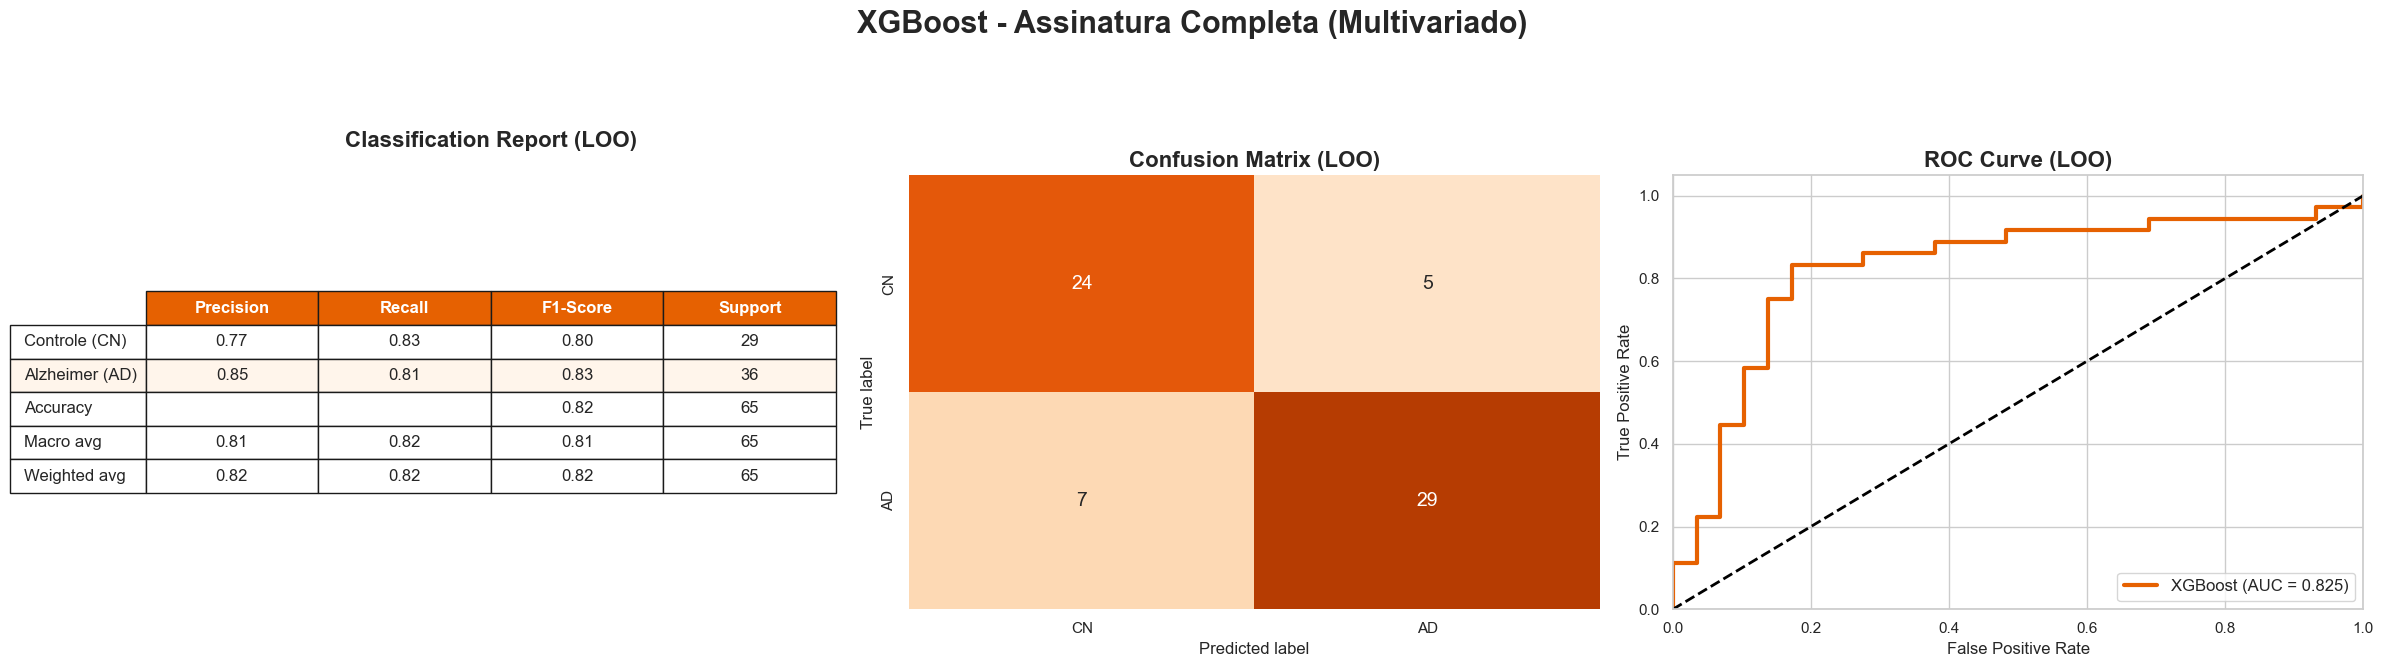

Dashboard salvo como: images\dashboard_XGBoost_Assinatura_Completa_(Multivariado).png

--- TABELA DE COMPARAÇÃO GERAL (INCLUINDO XGBoost) ---


,Modelo,Categoria,Accuracy,Sensibilidade,Especificidade,F1,AUC
11,SVM (Linear),Kuramoto Order,0.7385,0.6667,0.8276,0.7385,0.7126
12,SVM (Linear),Mutual Information,0.6462,0.5833,0.7241,0.6462,0.6964
13,SVM (Linear),Assinatura Completa (Multivariado),0.8000,0.7500,0.8621,0.8060,0.8170
14,XGBoost,Baseline (RBP),0.5846,0.6111,0.5517,0.6197,0.6475
15,XGBoost,Mean Frequency,0.5692,0.6111,0.5172,0.6111,0.5843
16,XGBoost,Lempel-Ziv Complexity,0.7077,0.7222,0.6897,0.7324,0.7375
17,XGBoost,Phase-Amplitude Coupling,0.7538,0.7778,0.7241,0.7778,0.7615
18,XGBoost,Kuramoto Order,0.6308,0.6389,0.6207,0.6571,0.7059
19,XGBoost,Mutual Information,0.6923,0.6944,0.6897,0.7143,0.7251
20,XGBoost,Assinatura Completa (Multivariado),0.8154,0.8056,0.8276,0.8286,0.8247


In [36]:
def evaluate_feature_xgb(df, feature_cols, category_name, model_name="XGBoost"):
    # Agrupa tirando a média por paciente
    df_grouped = df.groupby(['Subject_ID', 'Group'], as_index=False)[feature_cols].mean()
    
    X = df_grouped[feature_cols].values
    y = np.where(df_grouped['Group'] == 'A', 1, 0)
    groups = df_grouped['Subject_ID'].values
    
    # XGBoost lida com classes desbalanceadas através do parâmetro scale_pos_weight
    neg_class_count = np.sum(y == 0)
    pos_class_count = np.sum(y == 1)
    scale_pos_weight_val = neg_class_count / pos_class_count if pos_class_count > 0 else 1.0
    
    # Instancia o modelo XGBoost
    clf = XGBClassifier(
        n_estimators=100,          # Quantidade de árvores
        max_depth=6,               # Profundidade máxima
        learning_rate=0.1,         # Taxa de aprendizado
        scale_pos_weight=scale_pos_weight_val, # Balanceamento automático
        random_state=42, 
        n_jobs=-1,
        eval_metric='logloss'      # Evita avisos internos do XGBoost
    )
    
    loso = LeaveOneGroupOut()
    
    all_y_true = []
    all_y_pred = []
    all_y_prob = []
    
    print(f"Treinando {model_name} para: {category_name}...")
    
    for train_idx, test_idx in loso.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # XGBoost não precisa de StandardScaler nem de Imputer! 
        # Ele lida com os dados brutos e eventuais NaNs de forma automática.
        clf.fit(X_train, y_train)
        
        all_y_true.append(y_test[0])
        all_y_pred.append(clf.predict(X_test)[0])
        all_y_prob.append(clf.predict_proba(X_test)[0, 1])
        
    save_results(model_name, category_name, all_y_true, all_y_pred, all_y_prob)
    plot_dashboard(model_name, all_y_true, all_y_pred, all_y_prob, category_name)


# DEFINIÇÃO DAS FEATURES E BATERIA DE TESTES

df = pd.read_csv('eeg_features_baseline_data.csv')

features_rbp = ['Delta_RBP', 'Theta_RBP', 'Alpha_RBP', 'Beta_RBP', 'Gamma_RBP']
features_freq = ['Delta_Mean_Freq', 'Theta_Mean_Freq', 'Alpha_Mean_Freq', 'Beta_Mean_Freq', 'Gamma_Mean_Freq']
features_lzc = ['Delta_LZC', 'Theta_LZC', 'Alpha_LZC', 'Beta_LZC', 'Gamma_LZC']
features_pac = ['PAC_Delta_Beta', 'PAC_Delta_Gamma', 'PAC_Theta_Beta', 'PAC_Theta_Gamma', 'PAC_Alpha_Beta', 'PAC_Alpha_Gamma']
features_kuramoto = ['Kuramoto_Delta', 'Kuramoto_Theta', 'Kuramoto_Alpha', 'Kuramoto_Beta', 'Kuramoto_Gamma']
features_mi = ['MI_Delta', 'MI_Theta', 'MI_Alpha', 'MI_Beta', 'MI_Gamma']

features_todas = (features_rbp + features_freq + features_lzc + 
                  features_pac+ features_kuramoto + features_mi)

print(f"\nIniciando bateria XGBoost com {len(df['Subject_ID'].unique())} pacientes...\n")

evaluate_feature_xgb(df, features_rbp, "Baseline (RBP)")
evaluate_feature_xgb(df, features_freq, "Mean Frequency")
evaluate_feature_xgb(df, features_lzc, "Lempel-Ziv Complexity")
evaluate_feature_xgb(df, features_pac, "Phase-Amplitude Coupling")
evaluate_feature_xgb(df, features_kuramoto, "Kuramoto Order")
evaluate_feature_xgb(df, features_mi, "Mutual Information")

# O Teste Multivariado (36 variáveis brutas)
evaluate_feature_xgb(df, features_todas, "Assinatura Completa (Multivariado)")

# RESULTADOS FINAIS

print("\n" + "="*50)
print("--- TABELA DE COMPARAÇÃO GERAL (INCLUINDO XGBoost) ---")
print("="*50)
df_resultados = pd.read_csv('resultados_modelos.csv')
display(df_resultados.tail(10))

## Comparando os desempenhos

 1. CAMPEÕES POR MODELO (APENAS FEATURES ISOLADAS)


,Modelo,Categoria,Accuracy
3,Random Forest,Phase-Amplitude Coupling,0.7538
9,SVM (Linear),Lempel-Ziv Complexity,0.7538
17,XGBoost,Phase-Amplitude Coupling,0.7538


 2. CAMPEÕES POR MODELO (GERAL / COM MULTIVARIADO)


,Modelo,Categoria,Accuracy
20,XGBoost,Assinatura Completa (Multivariado),0.8154
13,SVM (Linear),Assinatura Completa (Multivariado),0.8000
3,Random Forest,Phase-Amplitude Coupling,0.7538


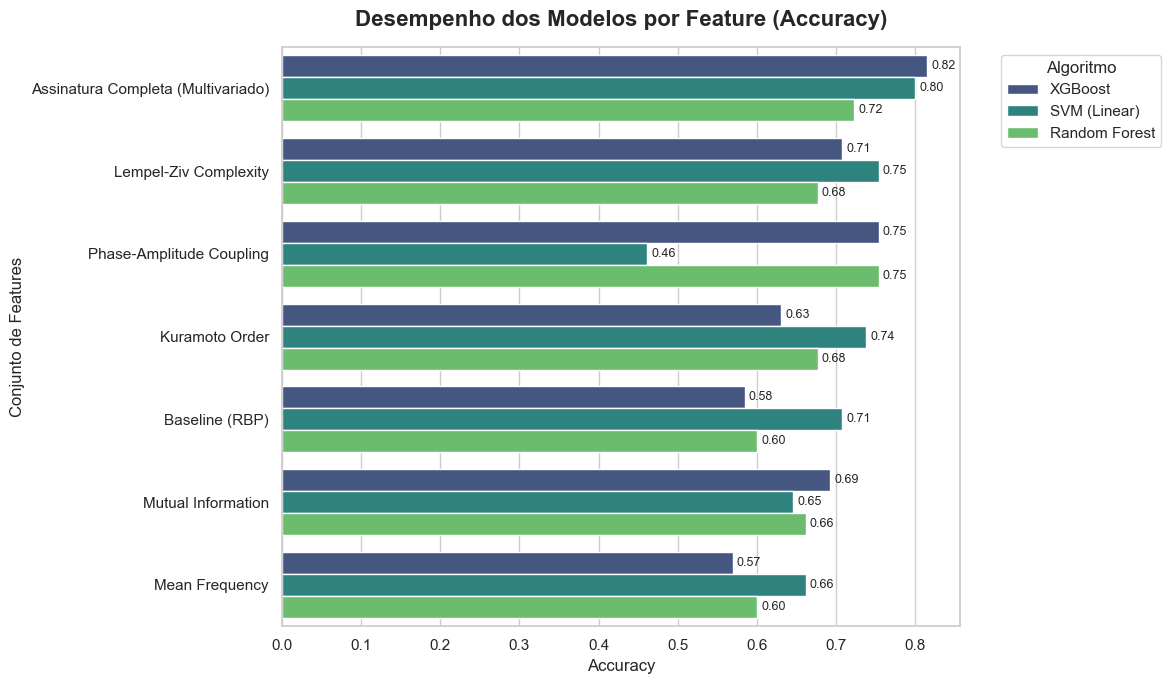

In [37]:
df_resultados = pd.read_csv('resultados_modelos.csv')
col_modelo = df_resultados.columns[0]
col_feature = df_resultados.columns[1]
col_metrica = df_resultados.columns[2]  # Geralmente é a Acurácia ou ROC AUC

# Nome exato dado à feature combinada no código anterior
nome_multivariado = "Assinatura Completa (Multivariado)"

# TABELA 1: CAMPEÕES DAS FEATURES ISOLADAS (SEM MULTIVARIADO)
# Filtra o dataset para remover a linha da Assinatura Completa
df_sem_multi = df_resultados[df_resultados[col_feature] != nome_multivariado]

# Encontra os índices dos melhores resultados por modelo dentro desse grupo
idx_melhores_sem = df_sem_multi.groupby(col_modelo)[col_metrica].idxmax()
df_campeoes_sem = df_sem_multi.loc[idx_melhores_sem].sort_values(by=col_metrica, ascending=False)

print(" 1. CAMPEÕES POR MODELO (APENAS FEATURES ISOLADAS)")
display(df_campeoes_sem[[col_modelo, col_feature, col_metrica]])


# TABELA 2: CAMPEÕES GERAIS (COM MULTIVARIADO NA DISPUTA)
idx_melhores_com = df_resultados.groupby(col_modelo)[col_metrica].idxmax()
df_campeoes_com = df_resultados.loc[idx_melhores_com].sort_values(by=col_metrica, ascending=False)

print(" 2. CAMPEÕES POR MODELO (GERAL / COM MULTIVARIADO)")
display(df_campeoes_com[[col_modelo, col_feature, col_metrica]])


# 3. VISUALIZAÇÃO GRÁFICA (Dashboard Comparativo)
# Configura o estilo visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Cria um gráfico de barras horizontais: Feature no Eixo Y, Métrica no Eixo X, Cores por Modelo
ax = sns.barplot(
    data=df_resultados.sort_values(by=col_metrica, ascending=False), 
    x=col_metrica, 
    y=col_feature, 
    hue=col_modelo, 
    palette="viridis"
)

# Ajustes de texto e layout
plt.title(f'Desempenho dos Modelos por Feature ({col_metrica})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel(col_metrica, fontsize=12)
plt.ylabel('Conjunto de Features', fontsize=12)

# Coloca a legenda fora do gráfico para não cobrir as barras
plt.legend(title='Algoritmo', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adiciona o valor exato no topo de cada barra para facilitar a leitura
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
df_resultados = pd.read_csv('resultados_modelos.csv')

# Remove duplicatas caso você tenha rodado a mesma célula várias vezes
# Mantém apenas a linha com a maior Acurácia para cada par (Modelo + Categoria)
idx_max = df_resultados.groupby(['Modelo', 'Categoria'])['Accuracy'].idxmax()
df_limpo = df_resultados.loc[idx_max]

# 2. RANKING ABSOLUTO (Melhor Combinação Modelo + Feature)

# Ordena por Acurácia e usa a AUC como critério de desempate
df_ranking_absoluto = df_limpo.sort_values(by=['Accuracy', 'AUC'], ascending=[False, False]).reset_index(drop=True)

# Cria uma coluna rankeada para facilitar a leitura (1º, 2º, 3º...)
df_ranking_absoluto.index = df_ranking_absoluto.index + 1
df_ranking_absoluto.index.name = 'Posição'

print("   RANKING ABSOLUTO (TODAS AS COMBINAÇÕES)")
display(df_ranking_absoluto[['Modelo', 'Categoria', 'Accuracy', 'AUC']])


# 3. RANKING DE ROBUSTEZ (Média da Feature em todos os modelos)

# Agrupa pela categoria e tira a média da Acurácia e AUC
df_ranking_medio = df_limpo.groupby('Categoria')[['Accuracy', 'AUC']].mean()
df_ranking_medio = df_ranking_medio.sort_values(by='Accuracy', ascending=False).reset_index()
df_ranking_medio.index = df_ranking_medio.index + 1
df_ranking_medio.index.name = 'Posição'

print(" RANKING DE ROBUSTEZ (MÉDIA GERAL DA FEATURE)")
display(df_ranking_medio)

   RANKING ABSOLUTO (TODAS AS COMBINAÇÕES)


,Modelo,Categoria,Accuracy,AUC
Posição,,,,
1,XGBoost,Assinatura Completa (Multivariado),0.8154,0.8247
2,SVM (Linear),Assinatura Completa (Multivariado),0.8000,0.8170
3,Random Forest,Phase-Amplitude Coupling,0.7538,0.7658
4,XGBoost,Phase-Amplitude Coupling,0.7538,0.7615
5,SVM (Linear),Lempel-Ziv Complexity,0.7538,0.7490
6,SVM (Linear),Kuramoto Order,0.7385,0.7126
7,Random Forest,Assinatura Completa (Multivariado),0.7231,0.7960
8,SVM (Linear),Baseline (RBP),0.7077,0.7921
9,XGBoost,Lempel-Ziv Complexity,0.7077,0.7375


 RANKING DE ROBUSTEZ (MÉDIA GERAL DA FEATURE)


,Categoria,Accuracy,AUC
Posição,,,
1,Assinatura Completa (Multivariado),0.779500,0.812567
2,Lempel-Ziv Complexity,0.712800,0.738300
3,Kuramoto Order,0.682067,0.707033
4,Mutual Information,0.666667,0.709300
5,Phase-Amplitude Coupling,0.656367,0.842433
6,Baseline (RBP),0.630767,0.704333
7,Mean Frequency,0.610233,0.630300


C:\Users\isabe\AppData\Local\Temp\ipykernel_22436\1281693942.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


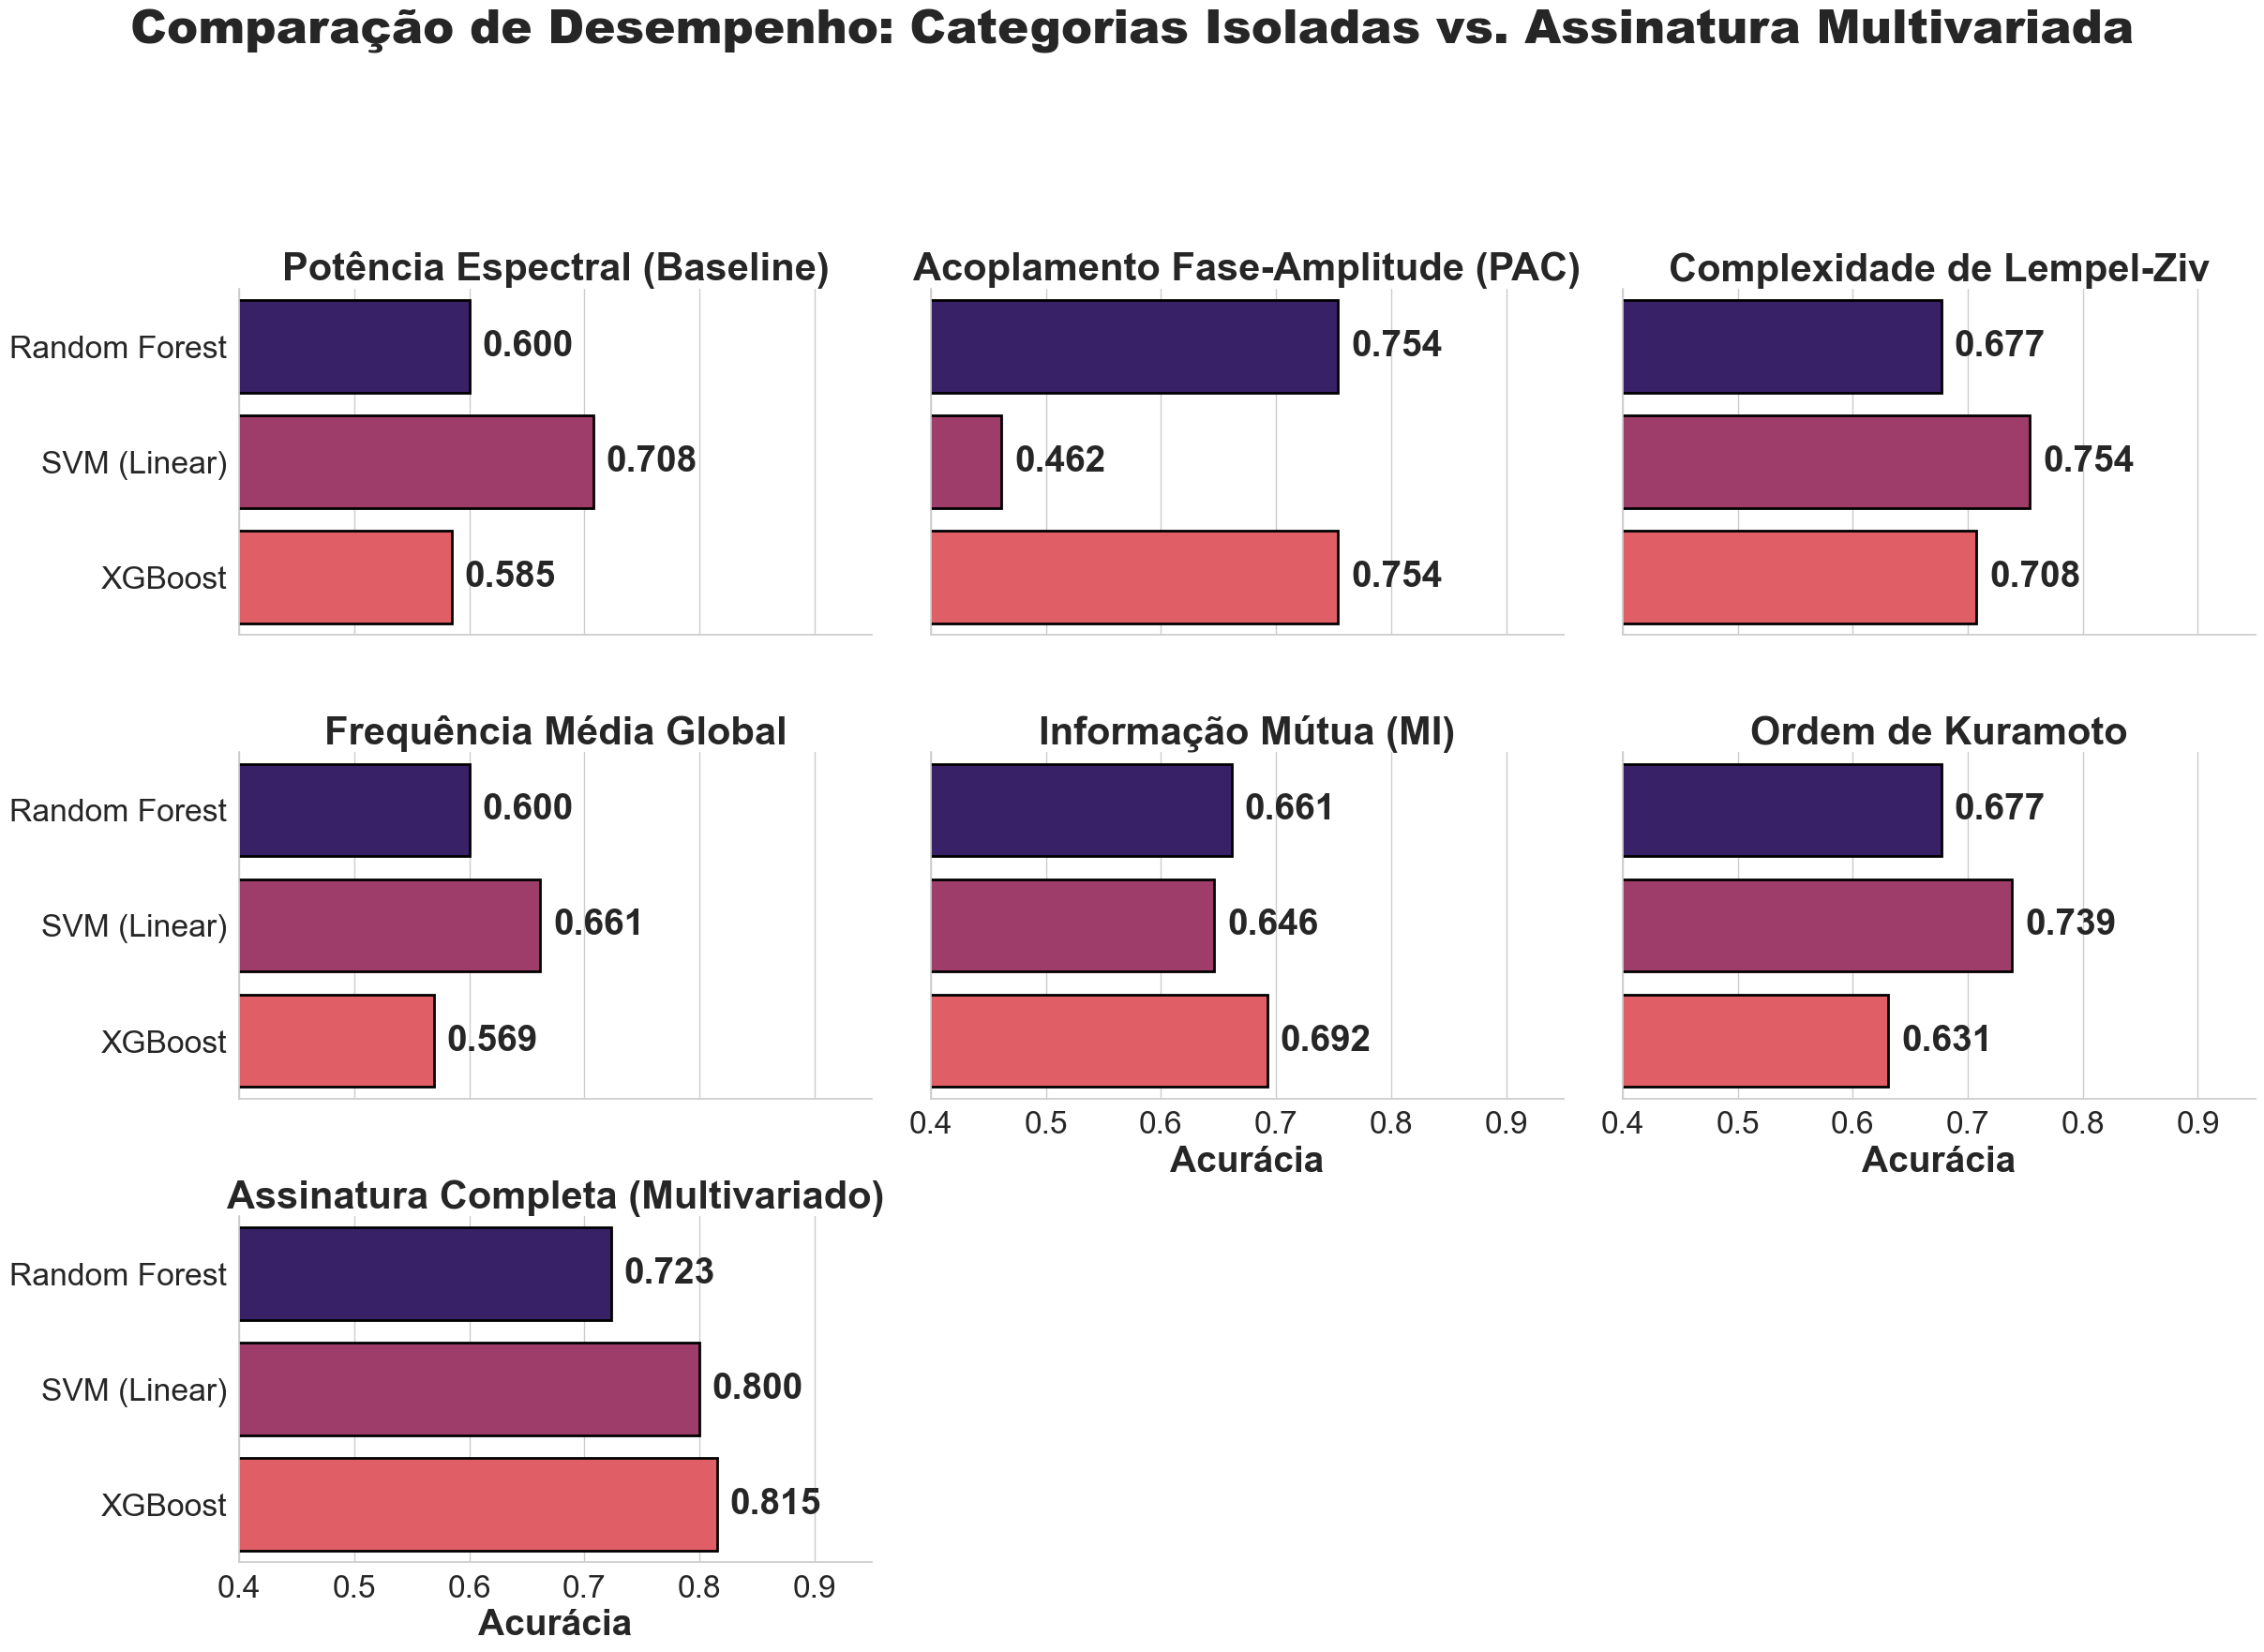

In [76]:
# CARREGAMENTO DOS RESULTADOS E SELEÇÃO DOS MELHORES
df_resultados = pd.read_csv('resultados_modelos.csv')

idx_max = df_resultados.groupby(['Modelo', 'Categoria'])['Accuracy'].idxmax()
df_plot = df_resultados.loc[idx_max].copy()

# TRADUÇÃO DOS NOMES DAS FEATURES PARA O GRÁFICO
dicionario_traducao = {
    'Baseline (RBP)': 'Potência Espectral (Baseline)',
    'Mean Frequency': 'Frequência Média Global',
    'Kuramoto Order': 'Ordem de Kuramoto',
    'Mutual Information': 'Informação Mútua (MI)',
    'Lempel-Ziv Complexity': 'Complexidade de Lempel-Ziv',
    'Phase-Amplitude Coupling': 'Acoplamento Fase-Amplitude (PAC)'
}

df_plot['Categoria'] = df_plot['Categoria'].replace(dicionario_traducao)

# DEFINIR A ORDEM (BASELINE PRIMEIRO, MULTIVARIADO POR ÚLTIMO)
todas_categorias = sorted(df_plot['Categoria'].unique().tolist())

# Encontra os nomes exatos na lista atual
nome_multivariado = [c for c in todas_categorias if 'Multivariado' in c or 'Assinatura' in c][0]
nome_baseline = [c for c in todas_categorias if 'Baseline' in c][0]

# Remove ambos da lista alfabética
todas_categorias.remove(nome_multivariado)
todas_categorias.remove(nome_baseline)

# Reconstrói a ordem forçando as posições
ordem_correta = [nome_baseline] + todas_categorias + [nome_multivariado]

sns.set_theme(style="whitegrid", font_scale=2.2) 

# APLICANDO A NOVA PALETA (Roxo, Magenta, Coral)
cores = ['#341671', '#AE2D68', '#F54952'] 

g = sns.catplot(
    data=df_plot,
    x='Accuracy',
    y='Modelo',
    col='Categoria',
    col_wrap=3,
    col_order=ordem_correta, 
    kind='bar',
    palette=cores,
    height=5.5,         
    aspect=1.5,         
    edgecolor='black',
    linewidth=2.0       
)

g.set_titles(col_template="{col_name}", size=30, weight='bold')

g.set_axis_labels("Acurácia", "", size=28, weight='bold')

g.set(xlim=(0.4, 0.95)) 

for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{width:.3f}', 
                        (width, p.get_y() + p.get_height() / 2.), 
                        ha='left', va='center', 
                        xytext=(10, 0), textcoords='offset points',
                        fontsize=28, fontweight='bold') 

plt.suptitle("Comparação de Desempenho: Categorias Isoladas vs. Assinatura Multivariada", 
             y=1.08, fontsize=36, fontweight='black')

plt.tight_layout()
plt.savefig("grafico_banner_nova_paleta_titulos_gigantes.png", dpi=300, bbox_inches='tight')
plt.show()

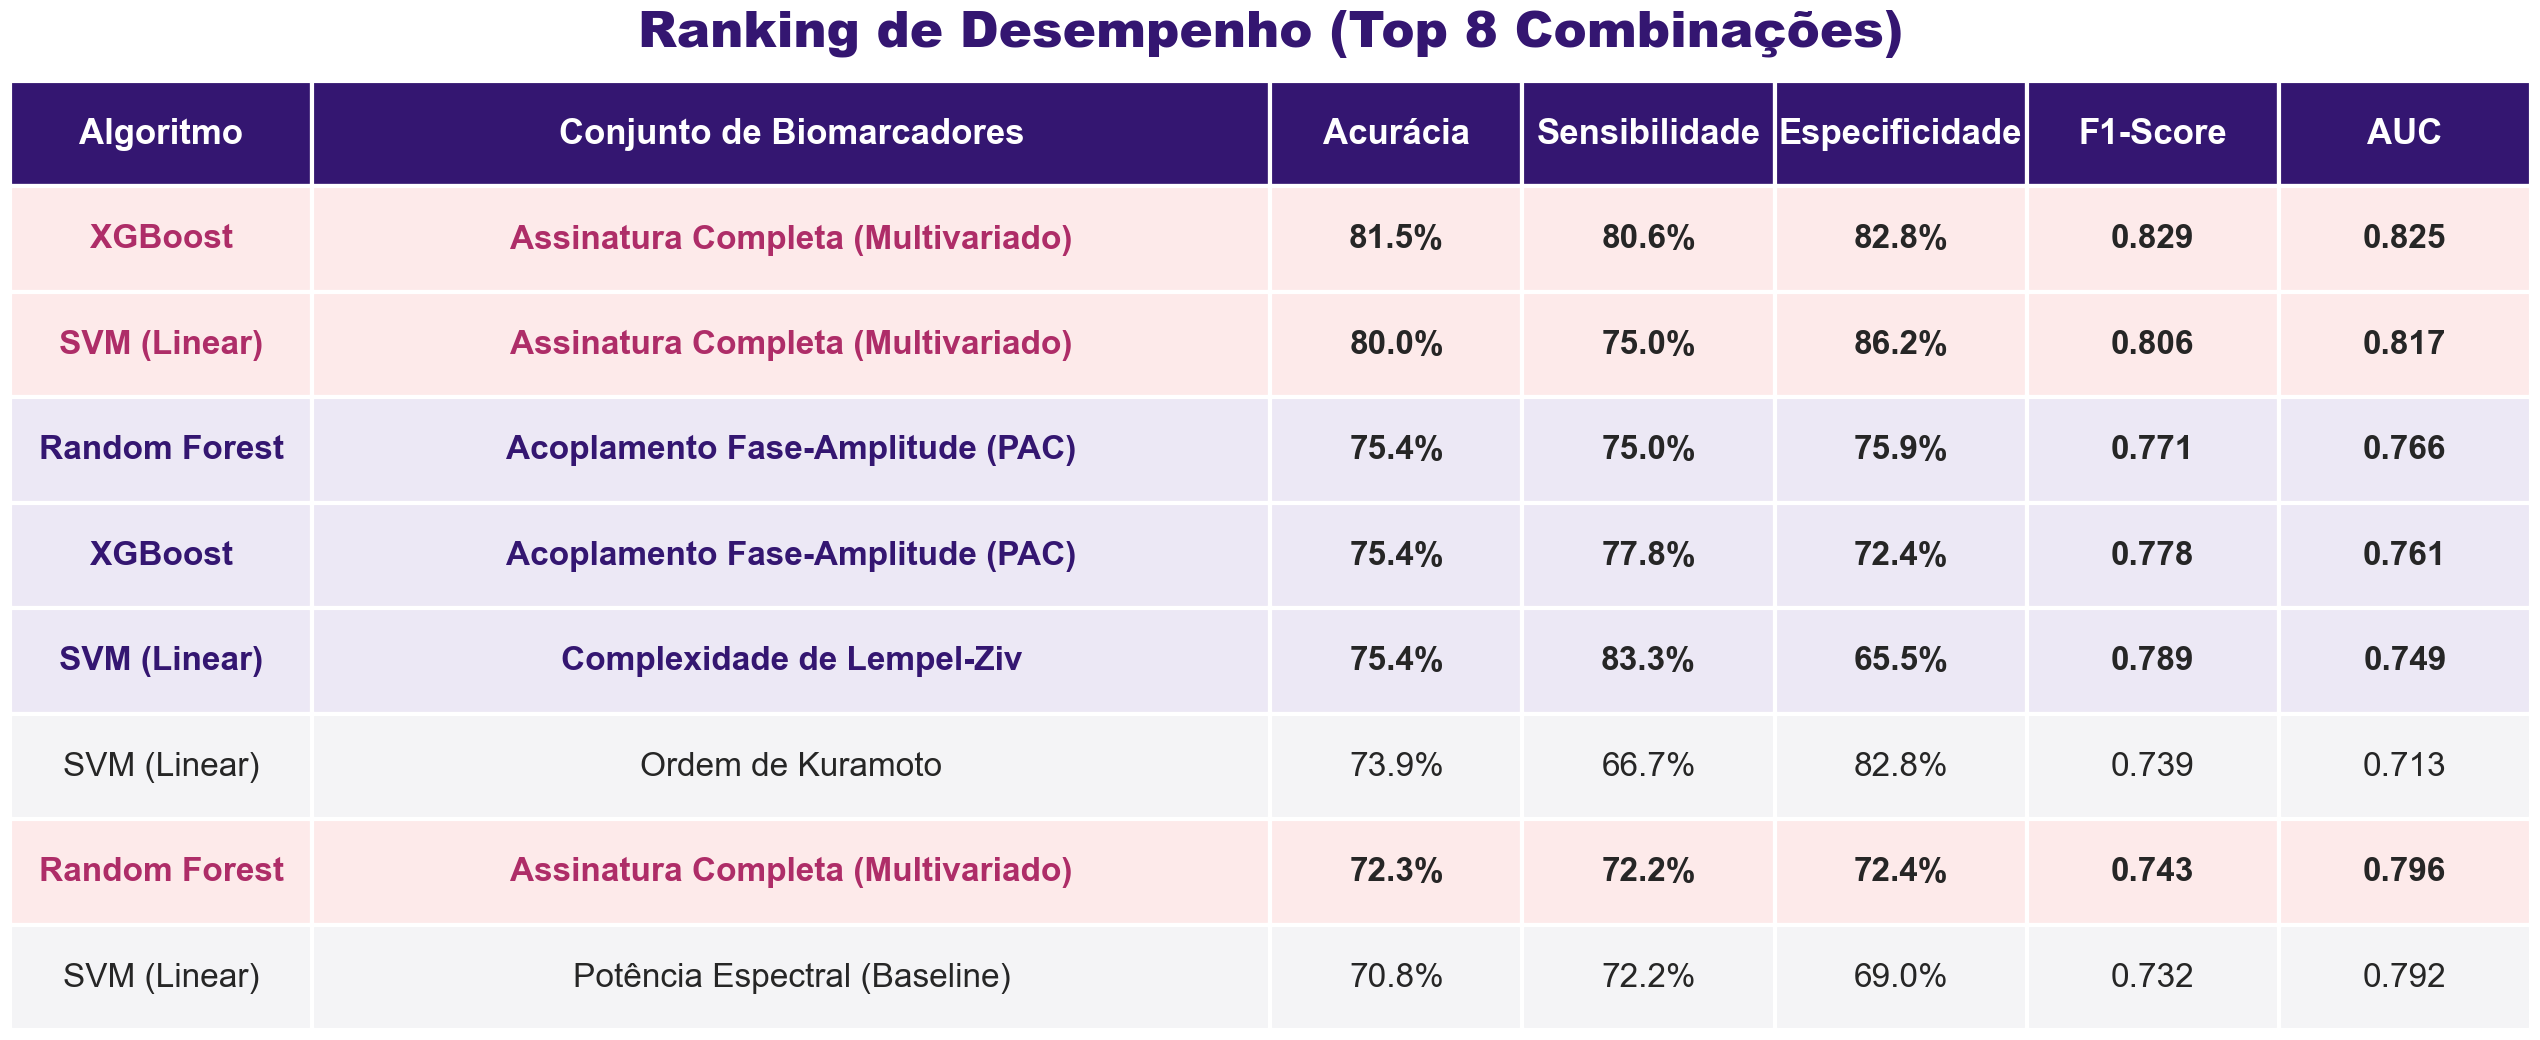

In [77]:
# CARREGAMENTO E PREPARAÇÃO DOS DADOS
df_resultados = pd.read_csv('resultados_modelos.csv')

idx_max = df_resultados.groupby(['Modelo', 'Categoria'])['Accuracy'].idxmax()
df_limpo = df_resultados.loc[idx_max].copy()

# Tradução dos nomes
dicionario_traducao = {
    'Baseline (RBP)': 'Potência Espectral (Baseline)',
    'Mean Frequency': 'Frequência Média Global',
    'Kuramoto Order': 'Ordem de Kuramoto',
    'Mutual Information': 'Informação Mútua (MI)',
    'Lempel-Ziv Complexity': 'Complexidade de Lempel-Ziv',
    'Phase-Amplitude Coupling': 'Acoplamento Fase-Amplitude (PAC)'
}

df_limpo['Categoria'] = df_limpo['Categoria'].replace(dicionario_traducao)
df_limpo.loc[df_limpo['Categoria'].str.contains('Multivari|Assinatura', case=False, na=False), 'Categoria'] = 'Assinatura Completa (Multivariado)'

# Seleciona os Top 8 melhores
df_top = df_limpo.sort_values(by=['Accuracy', 'AUC'], ascending=[False, False]).head(8)

# IDENTIFICANDO OS TOP 3 ISOLADOS E FORMATANDO OS NÚMEROS
linhas_top3_isolados = []
contador = 0
for i in range(len(df_top)):
    if 'Assinatura' not in df_top.iloc[i]['Categoria']:
        linhas_top3_isolados.append(i + 1) 
        contador += 1
        if contador == 3:
            break

def formata_pct(valor):
    v = valor if valor > 1 else valor * 100
    return f"{v:.1f}%"

df_top['Accuracy'] = df_top['Accuracy'].apply(formata_pct)
df_top['Sensibilidade'] = df_top['Sensibilidade'].apply(formata_pct)
df_top['Especificidade'] = df_top['Especificidade'].apply(formata_pct)
df_top['F1'] = df_top['F1'].apply(lambda x: f"{x:.3f}")
df_top['AUC'] = df_top['AUC'].apply(lambda x: f"{x:.3f}")

df_top = df_top.rename(columns={
    'Modelo': 'Algoritmo',
    'Categoria': 'Conjunto de Biomarcadores',
    'Accuracy': 'Acurácia',
    'F1': 'F1-Score'
})

# CRIAÇÃO DA TABELA VISUAL ALINHADA AO TOPO
fig, ax = plt.subplots(figsize=(26, 11)) 
ax.axis('off')

# Larguras das colunas
larguras_colunas = [0.12, 0.38, 0.10, 0.10, 0.10, 0.10, 0.10]

tabela = ax.table(
    cellText=df_top.values,
    colLabels=df_top.columns,
    cellLoc='center',
    bbox=[0, 0, 1, 1], 
    colWidths=larguras_colunas
)

tabela.auto_set_font_size(False)

tabela.set_fontsize(24)

for (row, col), cell in tabela.get_celld().items():
    cell.set_edgecolor('white') 
    cell.set_linewidth(3)       
    cell.PAD = 0.05 
    
    if row == 0:
        # CABEÇALHO
        cell.set_facecolor('#341671') 
        cell.get_text().set_color('white')
        cell.get_text().set_weight('heavy')
        
        cell.get_text().set_fontsize(25)
    else:
        texto_categoria = df_top.iloc[row-1]['Conjunto de Biomarcadores']
        
        # 1º DESTAQUE: Assinatura Completa (Multivariado)
        if 'Assinatura' in texto_categoria:
            cell.set_facecolor('#fdeaea') 
            cell.get_text().set_weight('bold')
            if col in [0, 1]: 
                cell.get_text().set_color('#AE2D68') 
                
        # 2º DESTAQUE: Top 3 Biomarcadores Isolados
        elif row in linhas_top3_isolados:
            cell.set_facecolor('#ece8f5') 
            cell.get_text().set_weight('bold')
            if col in [0, 1]:
                cell.get_text().set_color('#341671') 
                
        # DEMAIS RESULTADOS
        else:
            cell.set_facecolor('#f4f4f6' if row % 2 == 0 else '#ffffff')

plt.title("Ranking de Desempenho (Top 8 Combinações)", fontsize=36, fontweight='black', color='#341671', pad=25)

plt.tight_layout()
plt.savefig('tabela_banner_fontes_gigantes.png', dpi=300, bbox_inches='tight')
plt.show()